In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.feature_selection import VarianceThreshold
warnings.filterwarnings('ignore')
import joblib

In [2]:
prep = joblib.load("artifacts/preprocessing_fe/preprocessing_artifacts.joblib")
prep

{'scaler': StandardScaler(),
 'ohe_preprocess': ColumnTransformer(remainder='passthrough',
                   transformers=[('cat_ohe',
                                  OneHotEncoder(drop='first',
                                                handle_unknown='ignore',
                                                sparse_output=False),
                                  ['Partner', 'Dependents', 'PhoneService',
                                   'MultipleLines', 'InternetService',
                                   'OnlineSecurity', 'OnlineBackup',
                                   'DeviceProtection', 'TechSupport',
                                   'StreamingTV', 'StreamingMovies', 'Contract',
                                   'PaymentMethod', 'Tenure_bucket'])]),
 'log_cols': ['MonthlyCharges', 'TotalCharges'],
 'cont_cols': ['MonthlyCharges', 'TotalCharges']}

In [24]:
# from kaggle.api.kaggle_api_extended import KaggleApi
# api = KaggleApi()
# api.authenticate()
# data_url = 'subhadiphensh/customer-churn-prediction-dataset'
# api.dataset_download_files(dataset=data_url, path='./data', unzip=True)

In [11]:
df = pd.read_csv('data/train.csv')
df_test = pd.read_csv('data/test.csv')
print(df.shape, df_test.shape)

(594194, 21) (254655, 20)


In [14]:
data_sample = df.sample(1000)
data_sample.to_csv('./data/data_sample.csv')

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 594194 entries, 0 to 594193
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                594194 non-null  int64  
 1   gender            594194 non-null  object 
 2   SeniorCitizen     594194 non-null  int64  
 3   Partner           594194 non-null  object 
 4   Dependents        594194 non-null  object 
 5   tenure            594194 non-null  int64  
 6   PhoneService      594194 non-null  object 
 7   MultipleLines     594194 non-null  object 
 8   InternetService   594194 non-null  object 
 9   OnlineSecurity    594194 non-null  object 
 10  OnlineBackup      594194 non-null  object 
 11  DeviceProtection  594194 non-null  object 
 12  TechSupport       594194 non-null  object 
 13  StreamingTV       594194 non-null  object 
 14  StreamingMovies   594194 non-null  object 
 15  Contract          594194 non-null  object 
 16  PaperlessBilling  59

In [4]:
df.duplicated().sum()

0

In [6]:
def check_nulls(df):
    return (df.isnull().sum()
            .to_frame('null_count')
            .assign(null_ratio=lambda x: x.null_count / len(df))
            .query('null_count > 0')
            )
check_nulls(df)

,null_count,null_ratio


In [7]:
df = df.drop(columns='id')

In [8]:
cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    print(f'{col}: {df[col].unique()}')

gender: ['Male' 'Female']
Partner: ['Yes' 'No']
Dependents: ['Yes' 'No']
PhoneService: ['Yes' 'No']
MultipleLines: ['No' 'Yes' 'No phone service']
InternetService: ['DSL' 'Fiber optic' 'No']
OnlineSecurity: ['Yes' 'No' 'No internet service']
OnlineBackup: ['No' 'Yes' 'No internet service']
DeviceProtection: ['Yes' 'No' 'No internet service']
TechSupport: ['Yes' 'No' 'No internet service']
StreamingTV: ['No' 'Yes' 'No internet service']
StreamingMovies: ['No' 'Yes' 'No internet service']
Contract: ['One year' 'Two year' 'Month-to-month']
PaperlessBilling: ['Yes' 'No']
PaymentMethod: ['Mailed check' 'Credit card (automatic)' 'Electronic check'
 'Bank transfer (automatic)']
Churn: ['No' 'Yes']


In [9]:
num_cols = df.select_dtypes(include=['float', 'int']).columns
x_num = df[num_cols]

vt = VarianceThreshold(threshold=0.0)
x_num_vt = vt.fit_transform(x_num)

kept_cols = x_num.columns[vt.get_support()]
dropped_cols = x_num.columns[~vt.get_support()]

kept_cols, dropped_cols


(Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object'),
 Index([], dtype='object'))

In [10]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,594194.000000,594194.000000,594194.000000,594194.000000
mean,0.114102,36.577258,65.866223,2494.377057
std,0.317936,25.061922,31.067444,2353.916710
min,0.000000,1.000000,18.250000,18.800000
25%,0.000000,12.000000,29.900000,639.650000
50%,0.000000,35.000000,74.100000,1433.650000
75%,0.000000,62.000000,90.800000,4263.800000
max,1.000000,72.000000,118.750000,8684.800000


In [10]:
# df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

In [31]:
x = df.drop(columns=['Churn'])
y = df['Churn']


x_train, x_temp, y_train, y_temp = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

x_val, x_test, y_val, y_test = train_test_split(x_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print(f'x_train: {x_train.shape}, y_train: {y_train.shape}')
print(f'x_val: {x_val.shape}, y_val: {y_val.shape}')
print(f'x_test: {x_test.shape}, y_test: {y_test.shape}')

x_train: (475355, 19), y_train: (475355,)
x_val: (59419, 19), y_val: (59419,)
x_test: (59420, 19), y_test: (59420,)


# Preprocessing

# Explore Data Analysis (EDA)

In [32]:
x_train_eda = x_train.copy()
y_train_eda = y_train.copy()

In [33]:
num_cols = [
    c for c in x_train.select_dtypes(include=["int64", "float64"]).columns
    if x_train[c].nunique() > 10 # skip binary / dummy
]

num_cols

['tenure', 'MonthlyCharges', 'TotalCharges']

In [34]:
def drop_outlier_iqr(df, cols, k=1.5):
    before_rows = df.shape[0]
    df_clean = df.copy()
    bounds = {}
    
    print(f'total rows before: {before_rows}')
    
    for col in cols:
        q1 = df_clean[col].quantile(0.25)
        q3 = df_clean[col].quantile(0.75)
        iqr = q3 - q1
        
        lower = q1 - k * iqr
        upper = q3 + k * iqr
        bounds[col] = (lower, upper)
        
        before_col_rows = df_clean.shape[0]
        df_clean = df_clean[(df_clean[col] >=lower) & (df_clean[col] <= upper)]
        
        after_col_rows = df_clean.shape[0]
        
        print(f'\nColumn:{col}')
        print(f"  IQR Bounds : {lower:.3f}, {upper:.3f}")
        print(f"  Rows Before: {before_col_rows}")
        print(f"  Rows After : {after_col_rows}")
        print(f"  Dropped    : {before_col_rows - after_col_rows}")
        
    print("\n" + "-" * 40)
    print(f"Total rows after : {df_clean.shape[0]}")
    print(f"Total dropped    : {before_rows - df_clean.shape[0]}")
    print("-" * 40)
    
    return df_clean, bounds

In [35]:
x_train_clean, iqr_bounds = drop_outlier_iqr(x_train, num_cols)

# sinkronkan y_train
y_train_clean = y_train.loc[x_train_clean.index]

total rows before: 475355

Column:tenure
  IQR Bounds : -63.000, 137.000
  Rows Before: 475355
  Rows After : 475355
  Dropped    : 0

Column:MonthlyCharges
  IQR Bounds : -61.450, 182.150
  Rows Before: 475355
  Rows After : 475355
  Dropped    : 0

Column:TotalCharges
  IQR Bounds : -4796.125, 9700.075
  Rows Before: 475355
  Rows After : 475355
  Dropped    : 0

----------------------------------------
Total rows after : 475355
Total dropped    : 0
----------------------------------------


In [36]:
from pathlib import Path
import yaml

def extract_metadata(X, y=None):
    """Simpan Informasi data"""
    meta = {
        "n_rows": int(X.shape[0]),
        "n_cols": int(X.shape[1]),
        "columns": list(X.columns),
        "dtypes": {col: str(dtype) for col, dtype in X.dtypes.items()},
    }

    if y is not None:
        meta["target"] = {
            "n_rows": int(y.shape[0]),
            "dtype": str(y.dtype),
            "unique_values": sorted(y.unique().tolist())
        }

    return meta

In [37]:
import joblib

ARTIFACT_DIR = Path("artifacts") / "preprocessing"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

# Extract metadata
metadata = {
    "x_train": extract_metadata(x_train_clean, y_train_clean),
    "x_val": extract_metadata(x_val, y_val),
    "x_test":  extract_metadata(x_test, y_test)
}

# Save YAML metadata
with open(ARTIFACT_DIR / "dataset_metadata.yaml", "w") as f:
    yaml.safe_dump(metadata, f, sort_keys=False)

# Save datasets
joblib.dump(x_train_clean, ARTIFACT_DIR / "x_train_clean.joblib")
joblib.dump(y_train_clean, ARTIFACT_DIR / "y_train_clean.joblib")

joblib.dump(x_val, ARTIFACT_DIR / "x_val_enc.joblib")
joblib.dump(y_val, ARTIFACT_DIR / "y_val.joblib")

joblib.dump(x_test, ARTIFACT_DIR / "x_test_enc.joblib")
joblib.dump(y_test, ARTIFACT_DIR / "y_test.joblib")

['artifacts\\preprocessing\\y_test.joblib']

In [39]:
data_train_eda = pd.concat([x_train_eda, y_train_eda], axis=1)
data_train_eda

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
6165,Male,0,Yes,No,60,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,104.90,6273.40,No
565551,Female,1,No,No,47,Yes,Yes,DSL,No,Yes,No,No,Yes,Yes,One year,No,Electronic check,74.40,3847.75,No
85537,Female,0,No,Yes,11,Yes,No,DSL,No,No,No,Yes,No,Yes,Month-to-month,No,Bank transfer (automatic),59.45,669.45,No
137025,Female,0,Yes,Yes,35,Yes,Yes,DSL,Yes,Yes,No,Yes,No,No,One year,No,Bank transfer (automatic),62.25,2460.55,No
436494,Female,0,No,No,56,Yes,No,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,94.50,5149.45,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
317102,Male,0,Yes,Yes,28,No,No phone service,DSL,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Credit card (automatic),53.80,1559.50,No
177194,Male,0,No,No,3,Yes,Yes,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,54.25,235.05,Yes
143737,Female,0,No,No,10,Yes,No,Fiber optic,No,No,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,87.20,829.55,Yes
215738,Female,0,No,No,58,Yes,Yes,Fiber optic,No,Yes,Yes,Yes,Yes,Yes,Two year,Yes,Credit card (automatic),118.65,6521.90,No


# Univariate Analysis

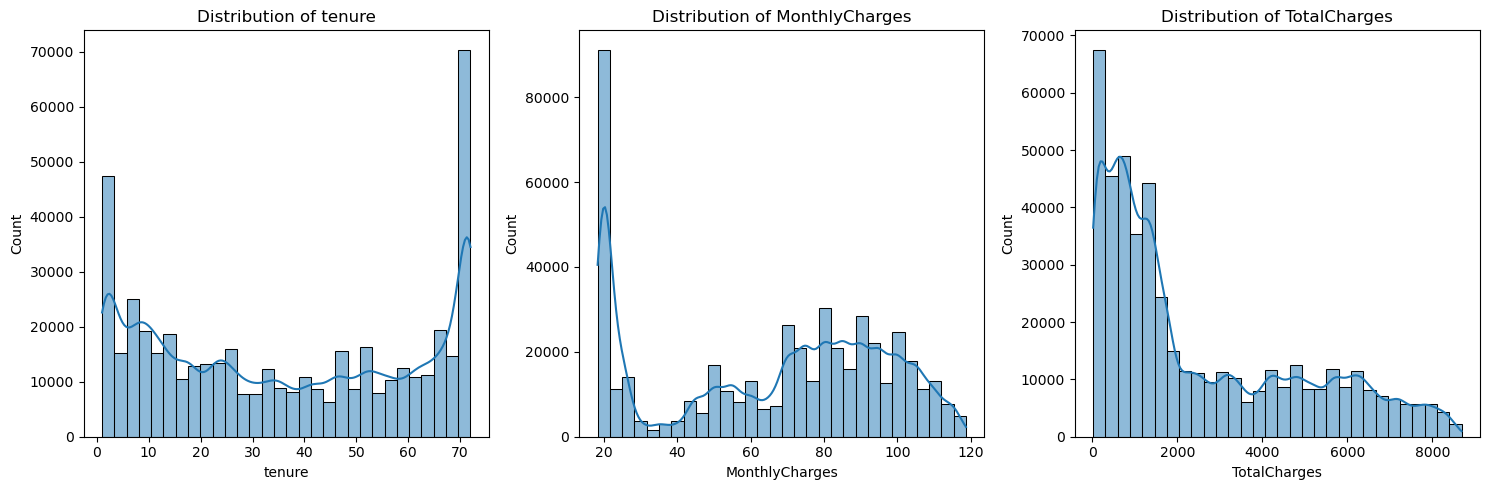

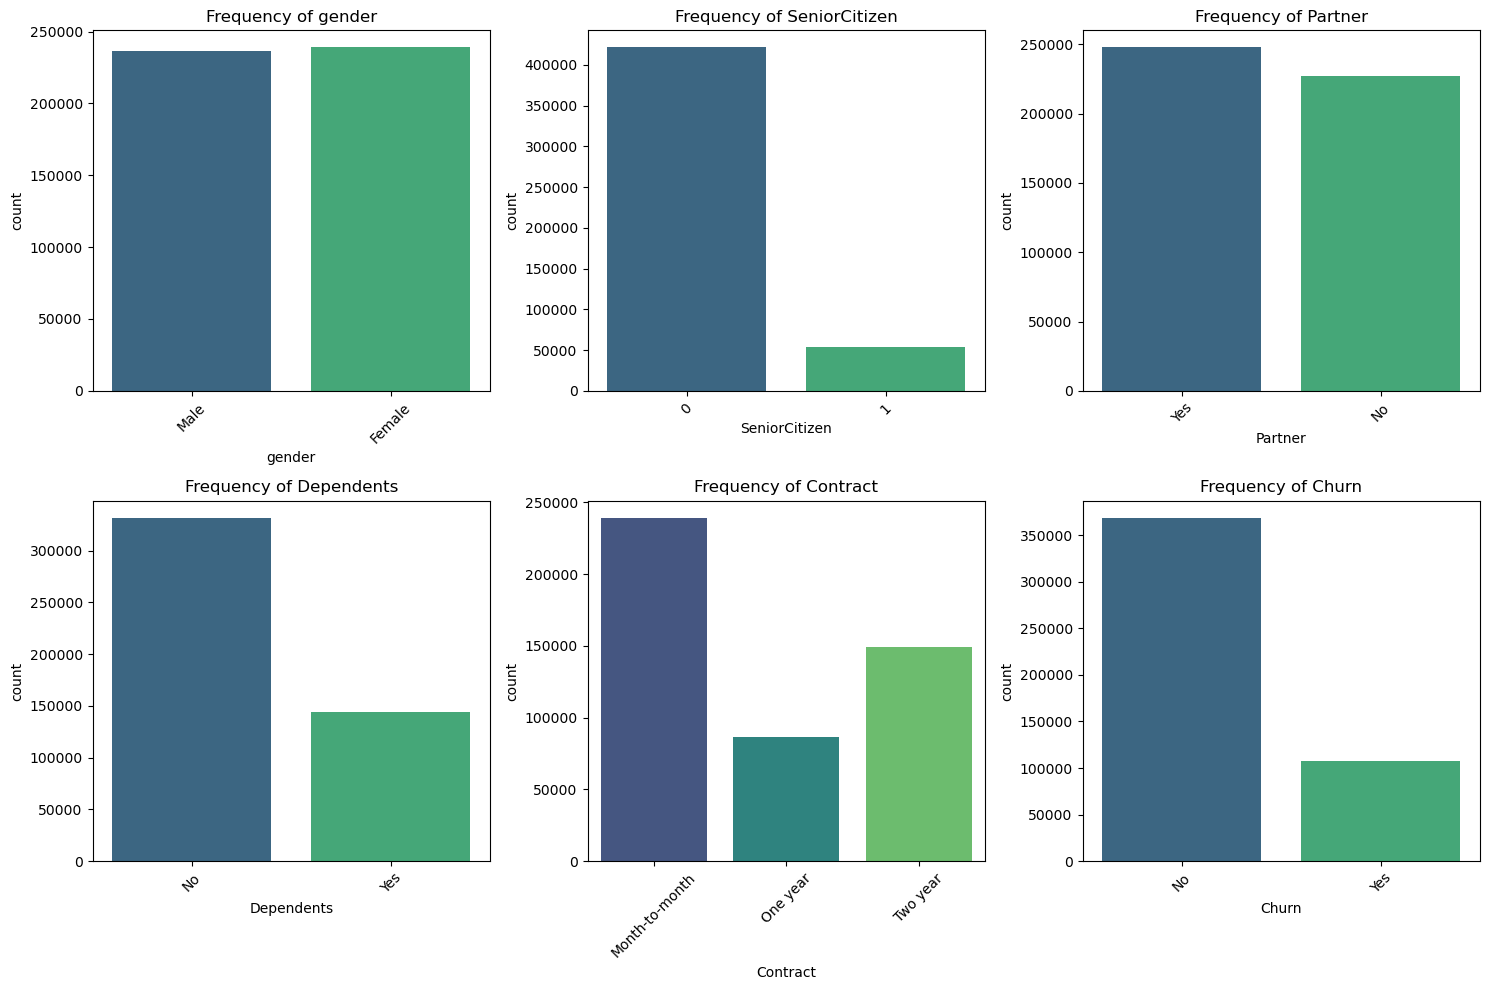

In [40]:
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
plt.figure(figsize=(15, 5))
for i, col in enumerate(num_cols):
    plt.subplot(1, 3, i+1)
    sns.histplot(data_train_eda[col], kde=True, bins=30)
    plt.title(f'Distribution of {col}')
plt.tight_layout()

# Categorical features frequency (Selecting key ones to avoid overcrowding)
cat_cols = ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'Contract', 'Churn']
plt.figure(figsize=(15, 10))
for i, col in enumerate(cat_cols):
    plt.subplot(2, 3, i+1)
    sns.countplot(data=data_train_eda, x=col, palette='viridis')
    plt.title(f'Frequency of {col}')
    plt.xticks(rotation=45)
plt.tight_layout()

In [18]:
import scipy.stats as stats
import numpy as np

def best_fit_distribution(data, bins=50):
    """Pengecekan distribusi data menggunakan statistik"""
    data = data.dropna().values

    # histogram data
    y, x = np.histogram(data, bins=bins, density=True)
    x_mid = (x[:-1] + x[1:]) / 2

    distributions = [
        stats.norm,
        stats.lognorm,
        stats.expon,
        stats.gamma,
        stats.beta,
        stats.uniform
    ]

    best_dist = None
    best_params = None
    best_sse = np.inf

    for dist in distributions:
        try:
            params = dist.fit(data)
            pdf = dist.pdf(x_mid, *params)
            sse = np.sum((y - pdf) ** 2)

            if sse < best_sse:
                best_sse = sse
                best_dist = dist
                best_params = params
        except Exception:
            pass

    return best_dist.name, best_params, best_sse

In [19]:
# initialize
results = []

# jalankan fungsi
for col in num_cols:
    dist_name, params, sse = best_fit_distribution(data_train_eda[col])
    results.append({
        "feature": col,
        "best_distribution": dist_name,
        "sse": sse
    })

dist_df = pd.DataFrame(results)
dist_df

,feature,best_distribution,sse
0,tenure,beta,5.957097e-03
1,MonthlyCharges,beta,5.195367e-03
2,TotalCharges,gamma,9.931899e-08


In [22]:
data_train_eda[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
tenure,475355.0,36.574846,25.052064,1.00,12.00,35.00,62.0,72.00
MonthlyCharges,475355.0,65.892025,31.078944,18.25,29.90,74.15,90.8,118.75
TotalCharges,475355.0,2495.627796,2355.014539,18.80,639.95,1434.65,4264.0,8684.80


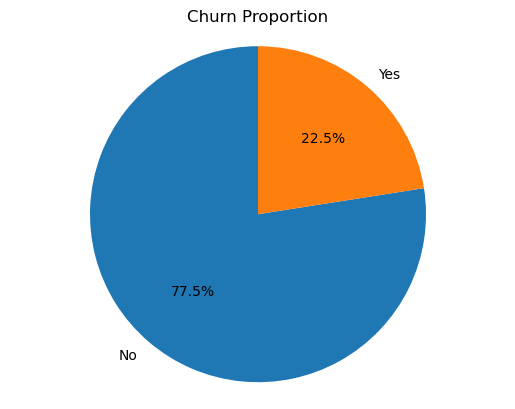

In [23]:
# hitung proporsi
churn_counts = data_train_eda['Churn'].value_counts(normalize=True).sort_index()

# pie chart
plt.figure()
plt.pie(
    churn_counts.values,
    labels=churn_counts.index,
    autopct='%1.1f%%',
    startangle=90
)
plt.title('Churn Proportion')
plt.axis('equal')
plt.show()

# Bivariate Analysis

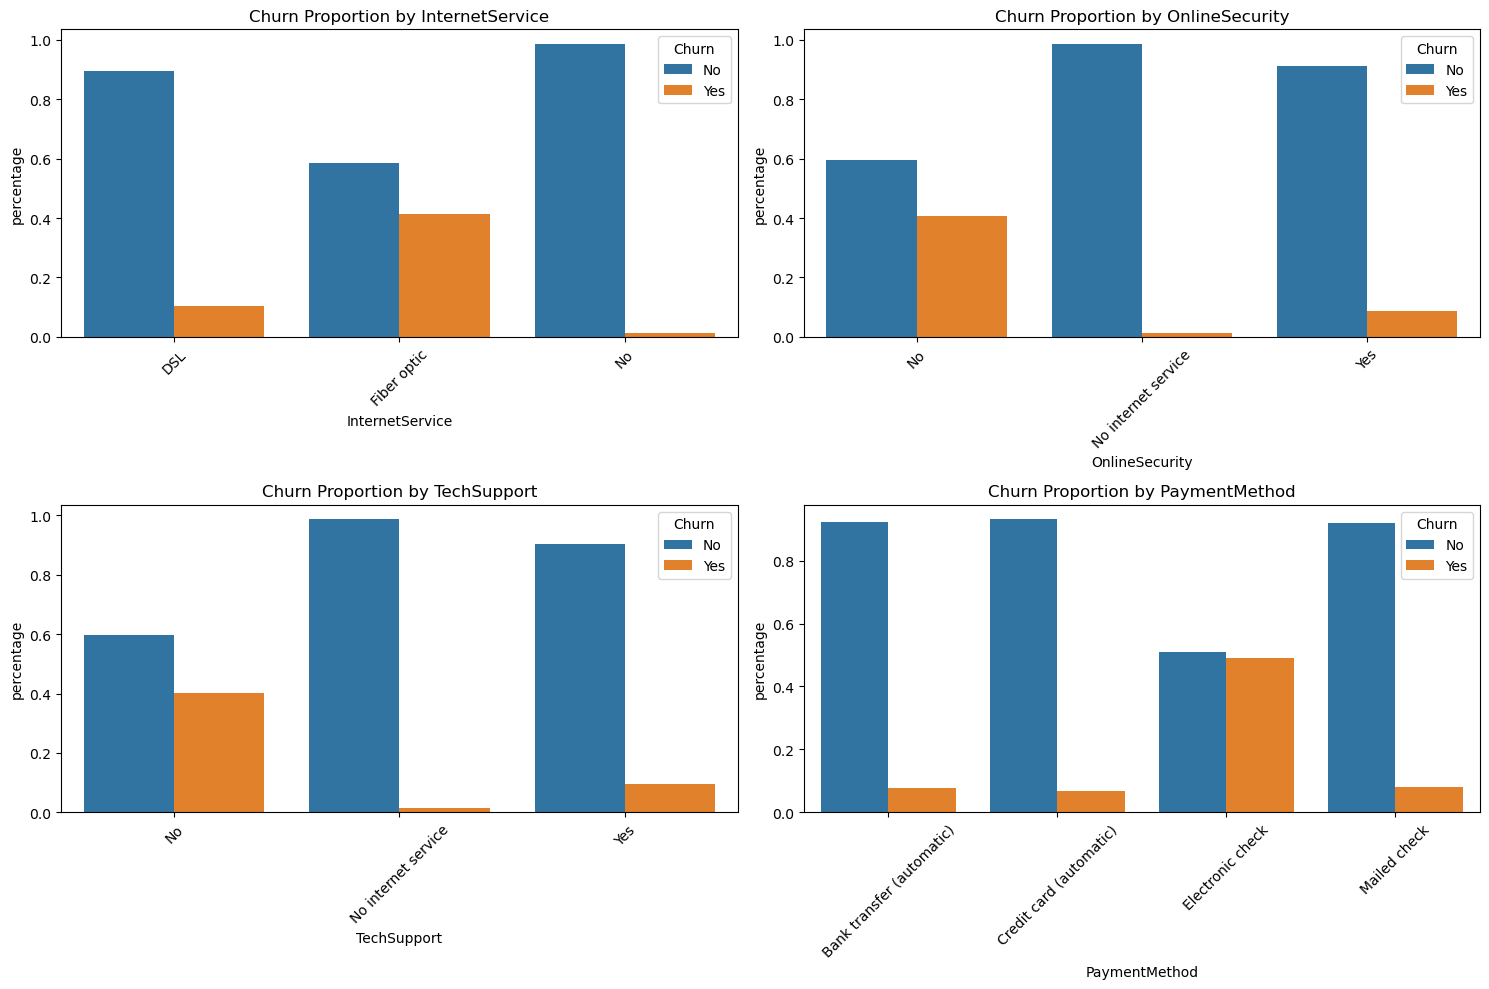

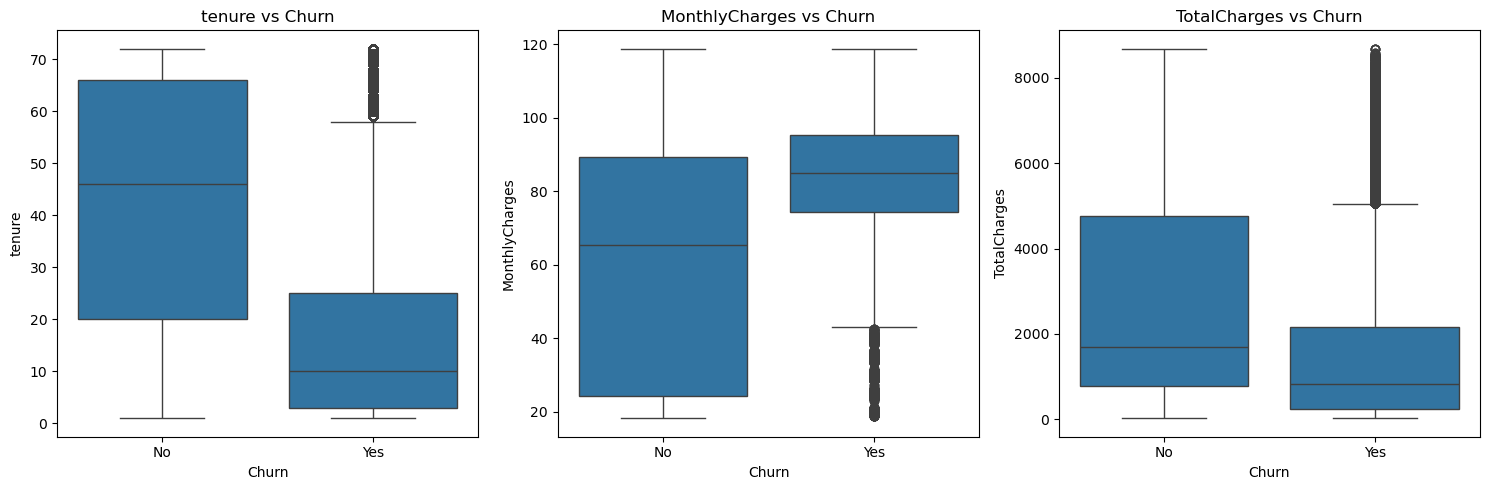

In [24]:
plt.figure(figsize=(15, 10))
cat_for_bivariate = ['InternetService', 'OnlineSecurity', 'TechSupport', 'PaymentMethod']
for i, col in enumerate(cat_for_bivariate):
    plt.subplot(2, 2, i+1)
    # Using proportions for better comparison
    prop_df = data_train_eda.groupby(col)['Churn'].value_counts(normalize=True).rename('percentage').reset_index()
    sns.barplot(data=prop_df, x=col, y='percentage', hue='Churn')
    plt.title(f'Churn Proportion by {col}')
    plt.xticks(rotation=45)
plt.tight_layout()

plt.figure(figsize=(15, 5))
for i, col in enumerate(num_cols):
    plt.subplot(1, 3, i+1)
    sns.boxplot(data=data_train_eda, x='Churn', y=col)
    plt.title(f'{col} vs Churn')
plt.tight_layout()

In [25]:
data_train_eda['Churn'] = data_train_eda['Churn'].map({'Yes': 1, 'No': 0})

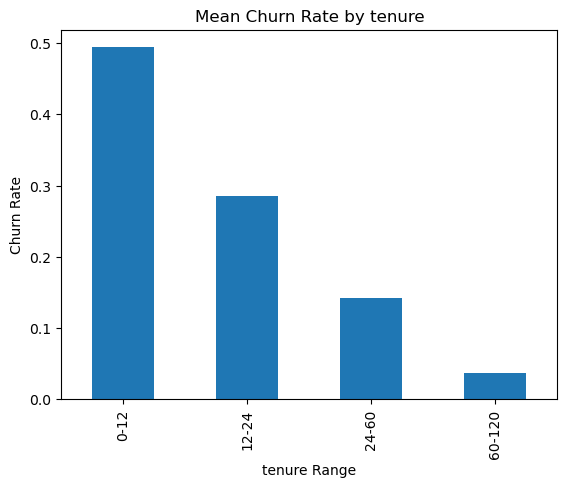

In [26]:
# binning Age
data_train_eda['tenure_bin'] = pd.cut(
    data_train_eda['tenure'],
    bins=[0, 12, 24, 60, 120, np.inf],
    labels=['0-12', '12-24', '24-60', '60-120', '>120'],
    ordered=True
)

# hitung churn rate + SORT
age_churn = (
    data_train_eda
    .groupby('tenure_bin', observed=True)['Churn']
    .mean()
    .sort_index()
)

# plot
plt.figure()
age_churn.plot(kind='bar')
plt.title('Mean Churn Rate by tenure')
plt.xlabel('tenure Range')
plt.ylabel('Churn Rate')
plt.show()

In [27]:
data_train_eda[['tenure', 'Churn']].corr()

,tenure,Churn
tenure,1.000000,-0.418231
Churn,-0.418231,1.000000


pada tenure menunjukkan bahwa adanya hubungan linear pada data yang mana, pelanggan yang baru (<12 bulan) itu rentan untuk churn. dan Churn rate menurun secara signifikan seiring lamanya berlangganan

Text(0.5, 1.0, 'Tenure Distribution by Churn')

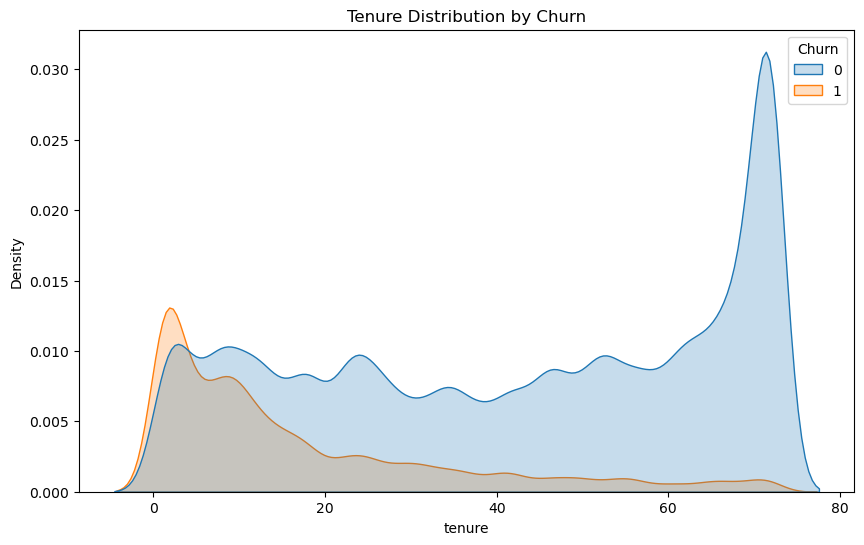

In [28]:
plt.figure(figsize=(10, 6))
sns.kdeplot(data=data_train_eda, x='tenure', hue='Churn', fill=True)
plt.title('Tenure Distribution by Churn')

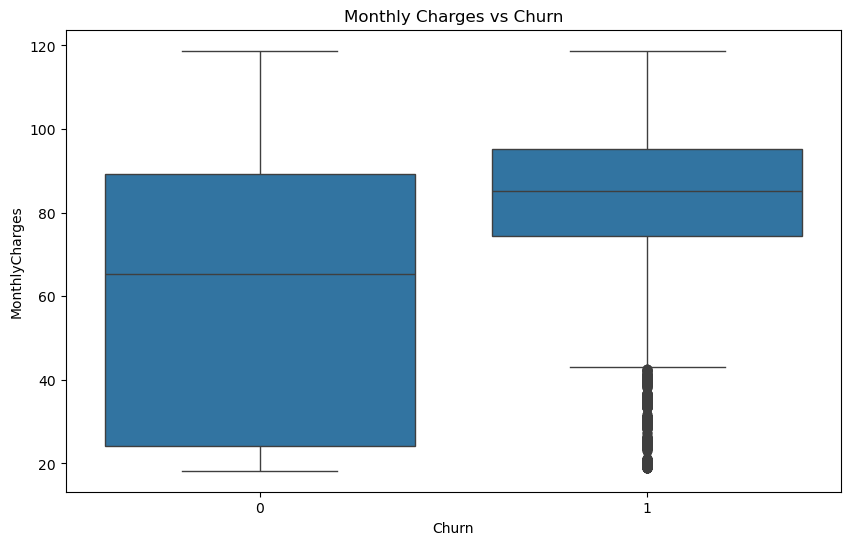

In [29]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=data_train_eda, x='Churn', y='MonthlyCharges')
plt.title('Monthly Charges vs Churn')
plt.savefig('monthly_charges_boxplot.png')

Text(0.5, 1.0, 'Correlation Matrix of Numerical Variables')

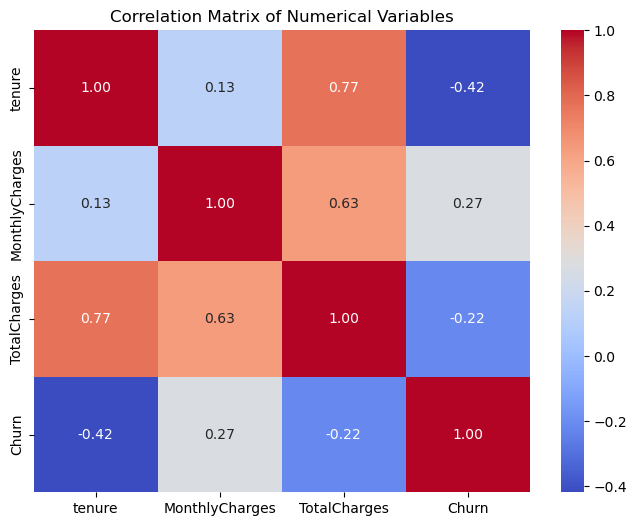

In [30]:
corr_matrix = data_train_eda[['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Variables')

Text(0.5, 1.0, 'Churn by Contract Type')

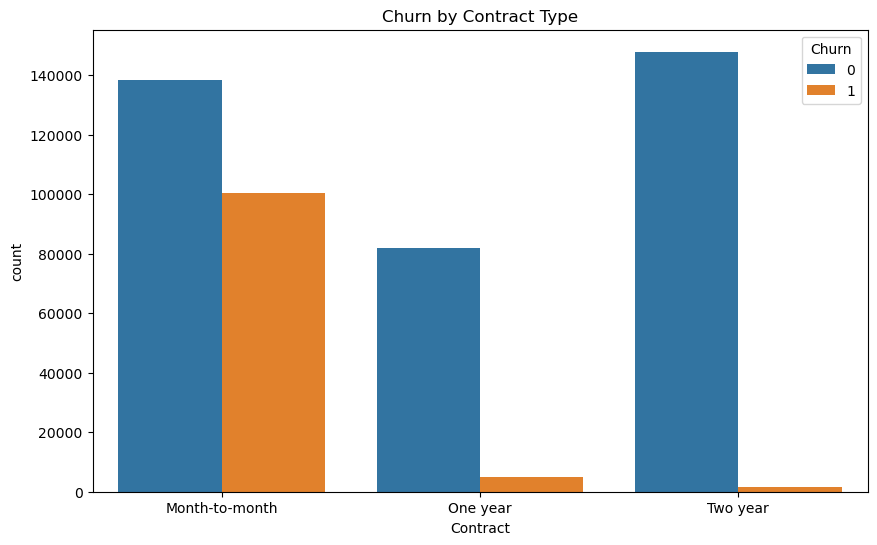

In [31]:
plt.figure(figsize=(10, 6))
sns.countplot(data=data_train_eda, x='Contract', hue='Churn')
plt.title('Churn by Contract Type')

# Multivariate

Text(0.5, 1.0, 'Correlation Heatmap')

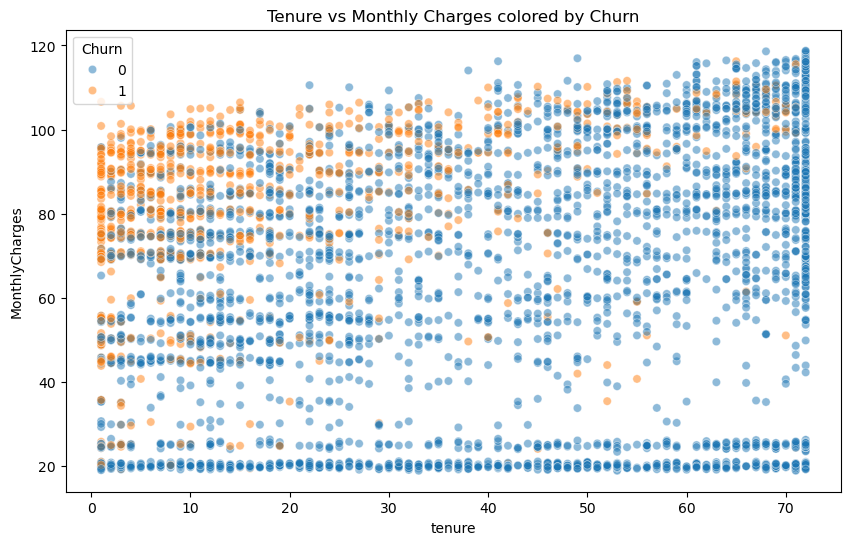

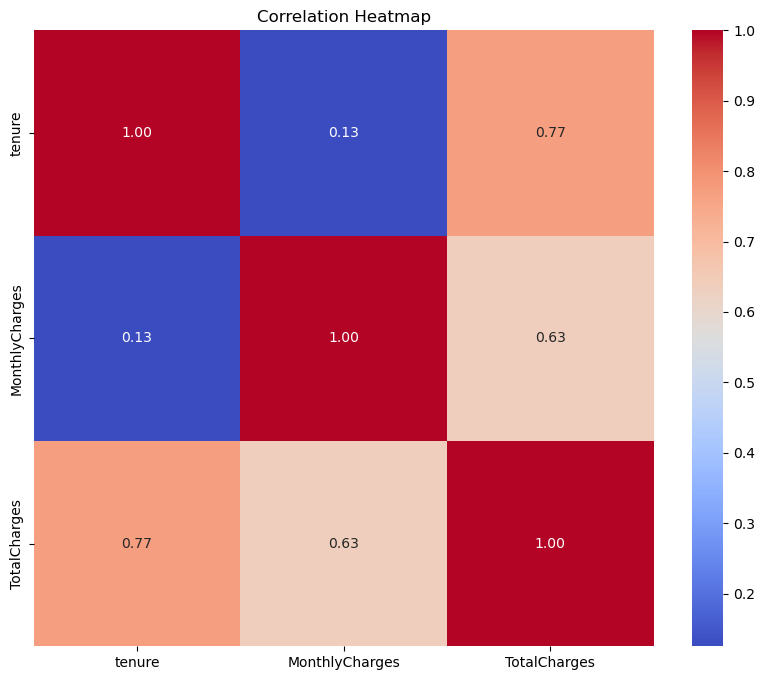

In [32]:
plt.figure(figsize=(10, 6))
df_sample = data_train_eda.sample(n=5000, random_state=42)
sns.scatterplot(data=df_sample, x='tenure', y='MonthlyCharges', hue='Churn', alpha=0.5)
plt.title('Tenure vs Monthly Charges colored by Churn')

plt.figure(figsize=(10, 8))
corr = data_train_eda[num_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')

In [33]:
service_cols = [
    'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies'
]

data_train_eda['TotalServices'] = (data_train_eda[service_cols] == 'Yes').sum(axis=1)
data_train_eda

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_bin,TotalServices
6165,Male,0,Yes,No,60,Yes,Yes,Fiber optic,No,Yes,...,Yes,Yes,Month-to-month,Yes,Electronic check,104.90,6273.40,0,24-60,6
565551,Female,1,No,No,47,Yes,Yes,DSL,No,Yes,...,Yes,Yes,One year,No,Electronic check,74.40,3847.75,0,24-60,5
85537,Female,0,No,Yes,11,Yes,No,DSL,No,No,...,No,Yes,Month-to-month,No,Bank transfer (automatic),59.45,669.45,0,0-12,3
137025,Female,0,Yes,Yes,35,Yes,Yes,DSL,Yes,Yes,...,No,No,One year,No,Bank transfer (automatic),62.25,2460.55,0,24-60,5
436494,Female,0,No,No,56,Yes,No,Fiber optic,No,No,...,Yes,Yes,Month-to-month,Yes,Electronic check,94.50,5149.45,0,24-60,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
317102,Male,0,Yes,Yes,28,No,No phone service,DSL,No,Yes,...,Yes,Yes,Month-to-month,Yes,Credit card (automatic),53.80,1559.50,0,24-60,4
177194,Male,0,No,No,3,Yes,Yes,DSL,Yes,No,...,No,No,Month-to-month,Yes,Electronic check,54.25,235.05,1,0-12,3
143737,Female,0,No,No,10,Yes,No,Fiber optic,No,No,...,Yes,Yes,Month-to-month,Yes,Electronic check,87.20,829.55,1,0-12,3
215738,Female,0,No,No,58,Yes,Yes,Fiber optic,No,Yes,...,Yes,Yes,Two year,Yes,Credit card (automatic),118.65,6521.90,0,24-60,7


Text(0.5, 1.0, 'Correlation Heatmap')

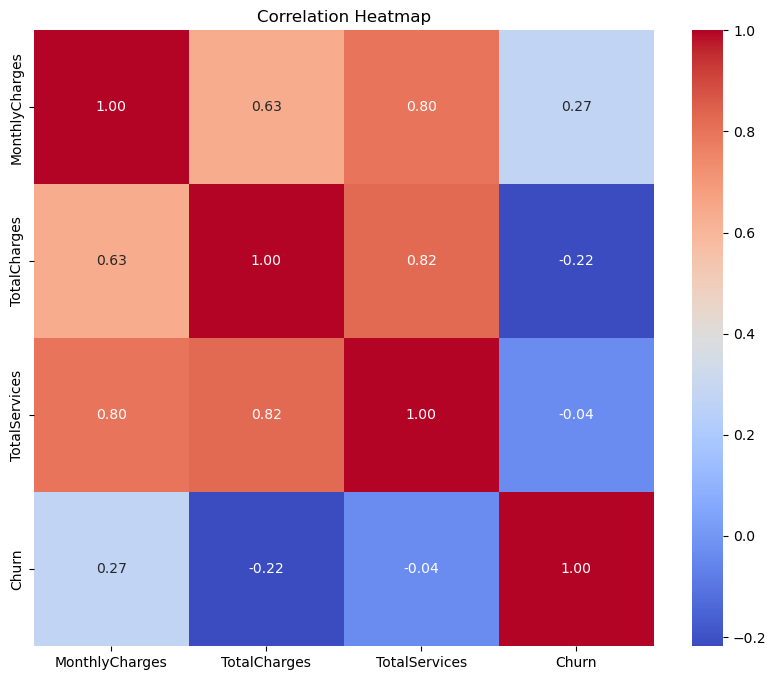

In [34]:
plt.figure(figsize=(10, 8))
corr = data_train_eda[['MonthlyCharges', 'TotalCharges', 'TotalServices', 'Churn']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')

In [35]:
# ambil kolom numerik
numeric_cols = data_train_eda.select_dtypes(include='number').columns

num_features = []
binary_features = []

for col in numeric_cols:
    n_unique = data_train_eda[col].nunique(dropna=True)

    if n_unique > 2:
        num_features.append(col)
    else:
        binary_features.append(col)

print("Numeric continuous features:")
print(num_features)

print("\nBinary features:")
print(binary_features)

Numeric continuous features:
['tenure', 'MonthlyCharges', 'TotalCharges', 'TotalServices']

Binary features:
['SeniorCitizen', 'Churn']


In [36]:
import math

def plot_scatter_num_vs_target(
    df,
    num_features,
    target_col='Churn',
    n_cols=3,
    jitter_std=0.03,
    figsize_per_row=4
):
    """
    Scatterplot bivariate: numeric continuous feature vs binary target.
    Digunakan untuk melihat lokasi titik churn (sanity check, bukan inferensi final).
    """

    n_rows = math.ceil(len(num_features) / n_cols)
    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(12, figsize_per_row * n_rows)
    )
    axes = axes.flatten()

    for i, col in enumerate(num_features):
        y_jitter = df[target_col] + np.random.normal(
            0, jitter_std, size=len(df)
        )

        axes[i].scatter(
            df[col],
            y_jitter,
            alpha=0.3
        )

        axes[i].set_title(f'{col} vs {target_col}')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel(f'{target_col} (jittered)')
        axes[i].set_yticks([0, 1])

    # hapus subplot kosong
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

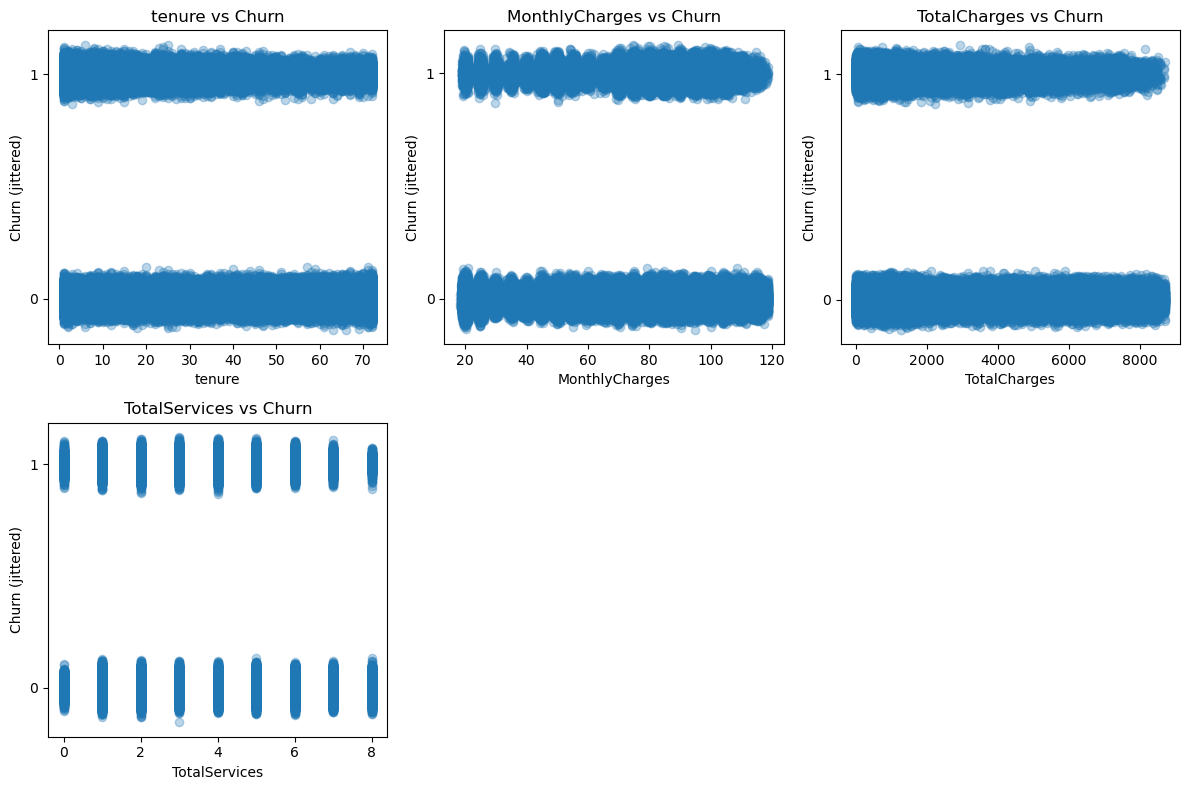

In [37]:
plot_scatter_num_vs_target(
    df=data_train_eda,
    num_features=num_features,
    target_col='Churn'
)

tidak ada titik kumpul tertentu pada feature-feature ini

In [38]:
import statsmodels.api as sm

# target
target_col = "Churn"

y = data_train_eda[target_col]
    
X = data_train_eda.drop(columns=[target_col])

# data numerik saja
X = X.select_dtypes(include=["number"])

# add intercept
X = sm.add_constant(X)

In [39]:
logit_model = sm.Logit(y, X)
result = logit_model.fit(maxiter=200)

print(result.summary())

Optimization terminated successfully.
         Current function value: 0.337039
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:                  Churn   No. Observations:               475355
Model:                          Logit   Df Residuals:                   475349
Method:                           MLE   Df Model:                            5
Date:                Fri, 06 Mar 2026   Pseudo R-squ.:                  0.3682
Time:                        05:16:47   Log-Likelihood:            -1.6021e+05
converged:                       True   LL-Null:                   -2.5356e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const             -2.8804      0.021   -136.876      0.000      -2.922      -2.839
SeniorCitizen    

In [40]:
from sklearn.feature_selection import VarianceThreshold

# ambil hanya kolom numerik
X_num = data_train_eda.select_dtypes(include=["int64", "float64"])

vt = VarianceThreshold(threshold=0.0)
X_num_vt = vt.fit_transform(X_num)

selected_features = X_num.columns[vt.get_support()]
removed_features = X_num.columns[~vt.get_support()]

print("Fitur numerik dipertahankan:")
print(selected_features)

print("\nFitur numerik dibuang (variance = 0):")
print(removed_features)

Fitur numerik dipertahankan:
Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn',
       'TotalServices'],
      dtype='object')

Fitur numerik dibuang (variance = 0):
Index([], dtype='object')


In [41]:
def compute_vif(X):
    vif_data = []

    for col in X.columns:
        # X_j sebagai target
        y = X[col]

        # fitur lain sebagai predictor
        X_others = X.drop(columns=[col])
        X_others = sm.add_constant(X_others)

        # regresi linear
        model = sm.OLS(y, X_others).fit()
        r_squared = model.rsquared

        # hitung VIF
        vif = 1 / (1 - r_squared)

        vif_data.append({
            "feature": col,
            "R_squared": r_squared,
            "VIF": vif
        })

    return pd.DataFrame(vif_data)

In [42]:
X = data_train_eda.select_dtypes(include=["int64", "float64"]).copy()
X = X.dropna()

# jalankan function
vif_df = compute_vif(X)
vif_df.sort_values("VIF", ascending=False)

,feature,R_squared,VIF
3,TotalCharges,0.903664,10.380335
2,MonthlyCharges,0.836339,6.110175
1,tenure,0.815358,5.415893
5,TotalServices,0.811293,5.299222
4,Churn,0.350378,1.539357
0,SeniorCitizen,0.097170,1.107628


In [21]:
def auto_column_types(
    df,
    target_col=None,
    binary_unique_threshold=2,
    categorical_unique_ratio=0.05
):
    """
    Automatically categorize dataframe columns into:
    - numeric
    - binary
    - categorical

    Rules:
    - binary      : numeric or object with exactly 2 unique values
    - categorical : object OR numeric with low unique ratio
    - numeric     : numeric and not binary/categorical
    """

    numeric_cols = []
    binary_cols = []
    categorical_cols = []

    for col in df.columns:
        if col == target_col:
            continue

        nunique = df[col].nunique(dropna=True)
        unique_ratio = nunique / len(df)

        # Binary
        if nunique == binary_unique_threshold:
            binary_cols.append(col)

        # Numeric
        elif pd.api.types.is_numeric_dtype(df[col]) and unique_ratio > categorical_unique_ratio:
            numeric_cols.append(col)

        # Categorical
        else:
            categorical_cols.append(col)

    return {
        "numeric": numeric_cols,
        "binary": binary_cols,
        "categorical": categorical_cols
    }


In [44]:
data_train_eda['TotalCharges'].nunique()

29941

In [45]:
data_train_eda.info()

<class 'pandas.core.frame.DataFrame'>
Index: 475355 entries, 6165 to 280641
Data columns (total 22 columns):
 #   Column            Non-Null Count   Dtype   
---  ------            --------------   -----   
 0   gender            475355 non-null  object  
 1   SeniorCitizen     475355 non-null  int64   
 2   Partner           475355 non-null  object  
 3   Dependents        475355 non-null  object  
 4   tenure            475355 non-null  int64   
 5   PhoneService      475355 non-null  object  
 6   MultipleLines     475355 non-null  object  
 7   InternetService   475355 non-null  object  
 8   OnlineSecurity    475355 non-null  object  
 9   OnlineBackup      475355 non-null  object  
 10  DeviceProtection  475355 non-null  object  
 11  TechSupport       475355 non-null  object  
 12  StreamingTV       475355 non-null  object  
 13  StreamingMovies   475355 non-null  object  
 14  Contract          475355 non-null  object  
 15  PaperlessBilling  475355 non-null  object  
 16  Paym

In [22]:
col_types = auto_column_types(data_train_eda, target_col="churn")

numeric_cols = col_types["numeric"]
binary_cols = col_types["binary"]
categorical_cols = col_types["categorical"]

print("Numeric:", numeric_cols)
print("Binary:", binary_cols)
print("Categorical:", categorical_cols)


Numeric: ['TotalCharges']
Binary: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']
Categorical: ['tenure', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod', 'MonthlyCharges']


In [47]:
from scipy.stats import pointbiserialr

def numeric_vs_binary(
    df,
    numeric_cols,
    target_col,
    alpha=0.05
):
    """
    Point-Biserial correlation for numeric vs binary target

    Adds:
    - significant (p < alpha)
    - effect_size (weak / moderate / strong)
    - direction (higher in class 1 / class 0)
    """

    rows = []

    for col in numeric_cols:
        corr, p = pointbiserialr(df[target_col], df[col])

        # significance
        significant = p < alpha

        # effect size interpretation
        abs_corr = abs(corr)
        if abs_corr < 0.1:
            effect = "very weak"
        elif abs_corr < 0.3:
            effect = "weak"
        elif abs_corr < 0.5:
            effect = "moderate"
        else:
            effect = "strong"

        # direction
        if corr > 0:
            direction = "higher when target = 1"
        elif corr < 0:
            direction = "higher when target = 0"
        else:
            direction = "no difference"

        rows.append({
            "feature": col,
            "correlation": corr,
            "abs_corr": abs_corr,
            "p_value": p,
            "significant": significant,
            "effect_size": effect,
            "direction": direction
        })

    return (
        pd.DataFrame(rows)
        .sort_values("abs_corr", ascending=False)
        .reset_index(drop=True)
    )

In [48]:
data_train_eda

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_bin,TotalServices
6165,Male,0,Yes,No,60,Yes,Yes,Fiber optic,No,Yes,...,Yes,Yes,Month-to-month,Yes,Electronic check,104.90,6273.40,0,24-60,6
565551,Female,1,No,No,47,Yes,Yes,DSL,No,Yes,...,Yes,Yes,One year,No,Electronic check,74.40,3847.75,0,24-60,5
85537,Female,0,No,Yes,11,Yes,No,DSL,No,No,...,No,Yes,Month-to-month,No,Bank transfer (automatic),59.45,669.45,0,0-12,3
137025,Female,0,Yes,Yes,35,Yes,Yes,DSL,Yes,Yes,...,No,No,One year,No,Bank transfer (automatic),62.25,2460.55,0,24-60,5
436494,Female,0,No,No,56,Yes,No,Fiber optic,No,No,...,Yes,Yes,Month-to-month,Yes,Electronic check,94.50,5149.45,0,24-60,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
317102,Male,0,Yes,Yes,28,No,No phone service,DSL,No,Yes,...,Yes,Yes,Month-to-month,Yes,Credit card (automatic),53.80,1559.50,0,24-60,4
177194,Male,0,No,No,3,Yes,Yes,DSL,Yes,No,...,No,No,Month-to-month,Yes,Electronic check,54.25,235.05,1,0-12,3
143737,Female,0,No,No,10,Yes,No,Fiber optic,No,No,...,Yes,Yes,Month-to-month,Yes,Electronic check,87.20,829.55,1,0-12,3
215738,Female,0,No,No,58,Yes,Yes,Fiber optic,No,Yes,...,Yes,Yes,Two year,Yes,Credit card (automatic),118.65,6521.90,0,24-60,7


In [49]:
numeric_vs_binary(data_train_eda, num_cols, 'Churn')

,feature,correlation,abs_corr,p_value,significant,effect_size,direction
0,tenure,-0.418231,0.418231,0.0,True,moderate,higher when target = 0
1,MonthlyCharges,0.272216,0.272216,0.0,True,weak,higher when target = 1
2,TotalCharges,-0.218220,0.218220,0.0,True,weak,higher when target = 0


In [50]:
from scipy.stats import chi2_contingency

def binary_vs_binary(
    df,
    binary_cols,
    target_col,
    alpha=0.05
):
    """
    Binary (categorical) vs Binary target analysis
    Uses Chi-Square test + Cramér's V

    Adds:
    - significant (p < alpha)
    - effect_size interpretation
    - interpretation text
    """

    rows = []

    for col in binary_cols:
        if col == target_col:
            continue

        ct = pd.crosstab(df[col], df[target_col])

        # chi-square test
        chi2, p_value, _, _ = chi2_contingency(ct)

        # cramér's v
        n = ct.sum().sum()
        v = np.sqrt(chi2 / (n * (min(ct.shape) - 1)))

        # significance
        significant = p_value < alpha

        # effect size interpretation
        if v < 0.1:
            effect = "very weak"
        elif v < 0.3:
            effect = "weak"
        elif v < 0.5:
            effect = "moderate"
        else:
            effect = "strong"

        # simple interpretation
        if not significant:
            insight = "no statistically significant association"
        else:
            insight = f"statistically significant ({effect} association)"

        rows.append({
            "feature": col,
            "cramers_v": v,
            "p_value": p_value,
            "significant": significant,
            "effect_size": effect,
            "interpretation": insight
        })

    return (
        pd.DataFrame(rows)
        .sort_values("cramers_v", ascending=False)
        .reset_index(drop=True)
    )


In [51]:
binary_cols

['gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'PhoneService',
 'PaperlessBilling',
 'Churn']

In [52]:
binary_vs_binary(df, binary_cols, 'Churn')

,feature,cramers_v,p_value,significant,effect_size,interpretation
0,PaperlessBilling,0.285103,0.000000e+00,True,weak,statistically significant (weak association)
1,Dependents,0.240364,0.000000e+00,True,weak,statistically significant (weak association)
2,SeniorCitizen,0.236355,0.000000e+00,True,weak,statistically significant (weak association)
3,Partner,0.228208,0.000000e+00,True,weak,statistically significant (weak association)
4,PhoneService,0.034835,8.013132e-159,True,very weak,statistically significant (very weak association)
5,gender,0.006804,1.561934e-07,True,very weak,statistically significant (very weak association)


In [53]:
# dir
ARTIFACT_DIR = Path("artifacts") / "preprocessing"

# Load metadata
with open(ARTIFACT_DIR / "dataset_metadata.yaml") as f:
    metadata = yaml.safe_load(f)

# Load datasets
x_train = joblib.load(ARTIFACT_DIR / "X_train_clean.joblib")
x_val = joblib.load(ARTIFACT_DIR / "X_val_enc.joblib")
x_test  = joblib.load(ARTIFACT_DIR / "X_test_enc.joblib")

y_train = joblib.load(ARTIFACT_DIR / "y_train_clean.joblib")
y_val = joblib.load(ARTIFACT_DIR / "y_val.joblib")
y_test  = joblib.load(ARTIFACT_DIR / "y_test.joblib")

# Assert helper
def assert_dataset(X, y, meta, name):
    assert X.shape[0] == meta["n_rows"], f"{name}: row count mismatch"
    assert X.shape[1] == meta["n_cols"], f"{name}: column count mismatch"
    assert list(X.columns) == meta["columns"], f"{name}: column order mismatch"

    for col, dtype in meta["dtypes"].items():
        assert str(X[col].dtype) == dtype, f"{name}: dtype mismatch in {col}"

    if y is not None:
        assert y.shape[0] == meta["target"]["n_rows"], f"{name}: target row mismatch"
        assert str(y.dtype) == meta["target"]["dtype"], f"{name}: target dtype mismatch"

# Run assertions
assert_dataset(x_train, y_train, metadata["x_train"], "x_train")
assert_dataset(x_val, y_val, metadata["x_val"], "x_val")
assert_dataset(x_test,  y_test,  metadata["x_test"],  "x_test")

# Quick sanity check
print("All datasets loaded and valated successfully")
print("Train shape:", x_train.shape)
print("val shape:", x_val.shape)
print("Test shape :", x_test.shape)


All datasets loaded and valated successfully
Train shape: (475355, 19)
val shape: (59419, 19)
Test shape : (59420, 19)


In [54]:
x_train

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
6165,Male,0,Yes,No,60,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,104.90,6273.40
565551,Female,1,No,No,47,Yes,Yes,DSL,No,Yes,No,No,Yes,Yes,One year,No,Electronic check,74.40,3847.75
85537,Female,0,No,Yes,11,Yes,No,DSL,No,No,No,Yes,No,Yes,Month-to-month,No,Bank transfer (automatic),59.45,669.45
137025,Female,0,Yes,Yes,35,Yes,Yes,DSL,Yes,Yes,No,Yes,No,No,One year,No,Bank transfer (automatic),62.25,2460.55
436494,Female,0,No,No,56,Yes,No,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,94.50,5149.45
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
317102,Male,0,Yes,Yes,28,No,No phone service,DSL,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Credit card (automatic),53.80,1559.50
177194,Male,0,No,No,3,Yes,Yes,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,54.25,235.05
143737,Female,0,No,No,10,Yes,No,Fiber optic,No,No,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,87.20,829.55
215738,Female,0,No,No,58,Yes,Yes,Fiber optic,No,Yes,Yes,Yes,Yes,Yes,Two year,Yes,Credit card (automatic),118.65,6521.90


In [55]:
drop_prefixes = [
    # 'TotalCharges',
    
    # no meaningful association
    'gender',
    'PaperlessBilling',
    'SeniorCitizen'
]

keep_cols_explicit = []

def exclude_columns_encoded(df: pd.DataFrame) -> pd.DataFrame:
    """Drop kolom dengan pola 'enc_'"""
    cols_to_drop = []

    # looping semua kolom
    for col in df.columns:
        for prefix in drop_prefixes:
            if col.startswith(prefix):
                cols_to_drop.append(col)

    # Safety: ensure kept prefixes are NOT dropped
    for col in df.columns:
        for keep in keep_cols_explicit:
            if col.startswith(keep) and col in cols_to_drop:
                cols_to_drop.remove(col)

    return df.drop(columns=cols_to_drop)

In [56]:
# jalankan fungsi
x_train = exclude_columns_encoded(x_train)
x_val = exclude_columns_encoded(x_val)
x_test  = exclude_columns_encoded(x_test)

print("Train shape:", x_train.shape)
print("Valid shape:", x_val.shape)
print("Test shape :", x_test.shape)

Train shape: (475355, 16)
Valid shape: (59419, 16)
Test shape : (59420, 16)


In [57]:
x_train

,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaymentMethod,MonthlyCharges,TotalCharges
6165,Yes,No,60,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Electronic check,104.90,6273.40
565551,No,No,47,Yes,Yes,DSL,No,Yes,No,No,Yes,Yes,One year,Electronic check,74.40,3847.75
85537,No,Yes,11,Yes,No,DSL,No,No,No,Yes,No,Yes,Month-to-month,Bank transfer (automatic),59.45,669.45
137025,Yes,Yes,35,Yes,Yes,DSL,Yes,Yes,No,Yes,No,No,One year,Bank transfer (automatic),62.25,2460.55
436494,No,No,56,Yes,No,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Electronic check,94.50,5149.45
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
317102,Yes,Yes,28,No,No phone service,DSL,No,Yes,Yes,No,Yes,Yes,Month-to-month,Credit card (automatic),53.80,1559.50
177194,No,No,3,Yes,Yes,DSL,Yes,No,No,No,No,No,Month-to-month,Electronic check,54.25,235.05
143737,No,No,10,Yes,No,Fiber optic,No,No,No,No,Yes,Yes,Month-to-month,Electronic check,87.20,829.55
215738,No,No,58,Yes,Yes,Fiber optic,No,Yes,Yes,Yes,Yes,Yes,Two year,Credit card (automatic),118.65,6521.90


In [58]:
# TENURE BINNING CONFIG
TENURE_BINS = [0, 6, 12, 24, 60, np.inf]
TENURE_LABELS = list(range(len(TENURE_BINS) - 1))

def apply_tenure_binning(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["Tenure_bucket"] = pd.cut(
        df["tenure"],
        bins=TENURE_BINS,
        labels=TENURE_LABELS,
        right=False
    )
    return df

x_train     = apply_tenure_binning(x_train)
x_val     = apply_tenure_binning(x_val)
x_test      = apply_tenure_binning(x_test)


# No NaN after binning
for name, df_ in {
    "train": x_train,
    "valid": x_val,
    "test": x_test,
}.items():
    assert df_["Tenure_bucket"].isna().sum() == 0, f"NaN found in {name}"

# All labels are valid
EXPECTED_LABELS = set(TENURE_LABELS)

for name, df_ in {
    "train": x_train,
    "valid": x_val,
    "test": x_test,
}.items():
    assert set(df_["Tenure_bucket"].unique()) <= EXPECTED_LABELS, \
        f"Invalid bucket label in {name}"

print('Bucket sukses')

Bucket sukses


In [59]:
x_train = x_train.drop(columns=["tenure"])
x_val = x_val.drop(columns=["tenure"])
x_test  = x_test.drop(columns=["tenure"])

In [60]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

def ohe_encode_sklearn(
    X_train: pd.DataFrame,
    X_valid: pd.DataFrame,
    X_test: pd.DataFrame,
    drop: str = "first"
):
    """
    One-hot encode kolom kategorikal menggunakan sklearn.
    - Fit hanya di TRAIN
    - Konsisten ke VALID & TEST
    - Handle unseen category
    - Bersihkan nama kolom (tanpa prefix sklearn)

    Returns:
        X_train_enc, X_valid_enc, X_test_enc, preprocess
    """

    # Deteksi kolom kategorikal
    cat_cols = X_train.select_dtypes(
        include=["object", "category"]
    ).columns.tolist()

    # OneHotEncoder
    ohe = OneHotEncoder(
        drop=drop,
        handle_unknown="ignore",
        sparse_output=False
    )

    # ColumnTransformer
    preprocess = ColumnTransformer(
        transformers=[
            ("cat_ohe", ohe, cat_cols)
        ],
        remainder="passthrough"
    )

    # Fit & transform
    X_train_enc = preprocess.fit_transform(X_train)
    X_valid_enc = preprocess.transform(X_valid)
    X_test_enc  = preprocess.transform(X_test)

    # Balik ke DataFrame
    feature_names = preprocess.get_feature_names_out()
    clean_cols = [col.split("__")[-1] for col in feature_names]

    X_train_enc = pd.DataFrame(
        X_train_enc, columns=clean_cols, index=X_train.index
    )
    X_valid_enc = pd.DataFrame(
        X_valid_enc, columns=clean_cols, index=X_valid.index
    )
    X_test_enc = pd.DataFrame(
        X_test_enc, columns=clean_cols, index=X_test.index
    )

    return X_train_enc, X_valid_enc, X_test_enc, preprocess


In [61]:
# ubah binning ke dalam bentuk OHE
x_train, x_val, x_test, preprocess = ohe_encode_sklearn(
    X_train=x_train, X_valid=x_val, X_test=x_test
)

In [62]:
x_train

,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,...,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Tenure_bucket_1,Tenure_bucket_2,Tenure_bucket_3,Tenure_bucket_4,MonthlyCharges,TotalCharges
6165,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,104.90,6273.40
565551,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,74.40,3847.75
85537,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,59.45,669.45
137025,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,62.25,2460.55
436494,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,94.50,5149.45
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
317102,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,53.80,1559.50
177194,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,54.25,235.05
143737,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,87.20,829.55
215738,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,...,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,118.65,6521.90


In [63]:
num_cols = x_train.select_dtypes(include="number").columns

# exclude data ordinal
cont_cols = [
    c for c in num_cols
    if x_train[c].nunique() > 10
]

cont_cols

['MonthlyCharges', 'TotalCharges']

In [64]:
from sklearn.preprocessing import StandardScaler

log_cols = cont_cols

# FIX DOMAIN LOG
for df in [x_train, x_val, x_test]:
    for col in log_cols:
        df[col] = df[col].clip(lower=0)

# LOG TRANSFORM
for df in [x_train, x_val, x_test]:
    for col in log_cols:
        df[col] = np.log1p(df[col])

# SCALING (FIT DI TRAIN)
scaler = StandardScaler()
x_train[cont_cols] = scaler.fit_transform(x_train[cont_cols])
x_val[cont_cols] = scaler.transform(x_val[cont_cols])
x_test[cont_cols]  = scaler.transform(x_test[cont_cols])


In [65]:
from imblearn.over_sampling import RandomOverSampler

ros = RandomOverSampler(random_state=42)
x_train_ros, y_train_ros = ros.fit_resample(x_train, y_train)

In [66]:
# ARTIFACT DIRECTORY
ARTIFACT_DIR = Path("artifacts") / "preprocessing_fe"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

# METADATA DATASET
metadata = {
    "x_train": extract_metadata(x_train, y_train),
    "x_train_ros": extract_metadata(x_train_ros, y_train_ros),
    "x_val": extract_metadata(x_val, y_val),
    "x_test": extract_metadata(x_test, y_test),
}

with open(ARTIFACT_DIR / "dataset_metadata.yaml", "w") as f:
    yaml.safe_dump(metadata, f, sort_keys=False)

# SAVE DATASETS
joblib.dump(x_train, ARTIFACT_DIR / "x_train_fe.joblib")
joblib.dump(y_train, ARTIFACT_DIR / "y_train_fe.joblib")

joblib.dump(x_train_ros, ARTIFACT_DIR / "x_train_ros.joblib")
joblib.dump(y_train_ros, ARTIFACT_DIR / "y_train_ros.joblib")

joblib.dump(x_val, ARTIFACT_DIR / "x_val_fe.joblib")
joblib.dump(y_val, ARTIFACT_DIR / "y_val_fe.joblib")

joblib.dump(x_test, ARTIFACT_DIR / "x_test_fe.joblib")
joblib.dump(y_test, ARTIFACT_DIR / "y_test_fe.joblib")

# SAVE PREPROCESSING ARTIFACTS
joblib.dump(
    {
        "scaler": scaler,
        "ohe_preprocess": preprocess,
        "log_cols": log_cols,
        "cont_cols": cont_cols,
    },
    ARTIFACT_DIR / "preprocessing_artifacts.joblib"
)

['artifacts\\preprocessing_fe\\preprocessing_artifacts.joblib']

# Modeling

In [67]:
# DIR
ARTIFACT_DIR = Path("artifacts") / "preprocessing_fe"

# LOAD METADATA
with open(ARTIFACT_DIR / "dataset_metadata.yaml") as f:
    metadata = yaml.safe_load(f)

# LOAD DATASETS
x_train      = joblib.load(ARTIFACT_DIR / "x_train_fe.joblib")
x_train_ros  = joblib.load(ARTIFACT_DIR / "x_train_ros.joblib")
x_val      = joblib.load(ARTIFACT_DIR / "x_val_fe.joblib")
x_test       = joblib.load(ARTIFACT_DIR / "x_test_fe.joblib")

y_train      = joblib.load(ARTIFACT_DIR / "y_train_fe.joblib")
y_train_ros  = joblib.load(ARTIFACT_DIR / "y_train_ros.joblib")
y_val      = joblib.load(ARTIFACT_DIR / "y_val_fe.joblib")
y_test       = joblib.load(ARTIFACT_DIR / "y_test_fe.joblib")

# ASSERT HELPER
def assert_dataset(X, y, meta, name):
    # X checks
    assert X.shape[0] == meta["n_rows"], f"{name}: row count mismatch"
    assert X.shape[1] == meta["n_cols"], f"{name}: column count mismatch"
    assert list(X.columns) == meta["columns"], f"{name}: column order mismatch"

    for col, dtype in meta["dtypes"].items():
        assert str(X[col].dtype) == dtype, f"{name}: dtype mismatch in {col}"

    # y checks
    if y is not None:
        assert y.shape[0] == meta["target"]["n_rows"], f"{name}: target row mismatch"
        assert str(y.dtype) == meta["target"]["dtype"], f"{name}: target dtype mismatch"

# RUN ASSERTIONS
assert_dataset(x_train,     y_train,     metadata["x_train"],     "x_train")
assert_dataset(x_train_ros, y_train_ros, metadata["x_train_ros"], "x_train_ros")
assert_dataset(x_val,     y_val,     metadata["x_val"],     "x_val")
assert_dataset(x_test,      y_test,      metadata["x_test"],      "x_test")

# SANITY CHECK
print("All datasets loaded and validated successfully")
print("Train shape :", x_train.shape)
print("ROS shape   :", x_train_ros.shape)
print("Valid shape :", x_val.shape)
print("Test shape  :", x_test.shape)


All datasets loaded and validated successfully
Train shape : (475355, 30)
ROS shape   : (736602, 30)
Valid shape : (59419, 30)
Test shape  : (59420, 30)


In [68]:
from concurrent.futures import ProcessPoolExecutor, as_completed

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import recall_score, roc_auc_score, average_precision_score

from xgboost import XGBClassifier
import time

from sklearn.metrics import classification_report
from sklearn.ensemble import VotingClassifier

In [69]:
y_train_ros = y_train_ros.map({'Yes': 1, 'No': 0})
y_train = y_train.map({'Yes': 1, 'No': 0})
y_val = y_val.map({'Yes': 1, 'No': 0})
y_test = y_test.map({'Yes': 1, 'No': 0})

In [70]:
y_train

6165      0
565551    0
85537     0
137025    0
436494    0
         ..
317102    0
177194    1
143737    1
215738    0
280641    0
Name: Churn, Length: 475355, dtype: int64

In [71]:
# Base model
from sklearn.dummy import DummyClassifier

dummy = DummyClassifier(strategy="most_frequent", random_state=42)
dummy.fit(x_train_ros, y_train_ros)

y_pred = dummy.predict(x_train_ros)
y_proba = dummy.predict_proba(x_train_ros)[:, 1]

print(f"Recall  : {recall_score(y_train_ros, y_pred):.4f}")
print(f"PR-AUC  : {average_precision_score(y_train_ros, y_proba):.4f}")

Recall  : 0.0000
PR-AUC  : 0.5000


In [72]:
import logging
from pathlib import Path

def get_logger(name: str):
    LOG_DIR = Path("artifacts/logs")
    LOG_DIR.mkdir(parents=True, exist_ok=True)

    log_file = LOG_DIR / f"{name}.log"

    logger = logging.getLogger(name)
    logger.setLevel(logging.INFO)
    logger.handlers.clear()  # penting: hindari duplicate

    formatter = logging.Formatter(
        "%(asctime)s | %(levelname)s | %(message)s"
    )

    # file handler (BEDA FILE)
    file_handler = logging.FileHandler(log_file)
    file_handler.setFormatter(formatter)

    # console handler
    console_handler = logging.StreamHandler()
    console_handler.setFormatter(formatter)

    logger.addHandler(file_handler)
    logger.addHandler(console_handler)
    logger.propagate = False

    return logger


In [73]:
# initialize logger
train_logger = get_logger("training")
cv_logger = get_logger("cross_validation")
logger_re_train = get_logger("re_training")
test_logger = get_logger("test_evaluation")

In [74]:
def evaluate_model(model, X, y, threshold=0.5):
    """Evaluate Model"""
    y_prob = model.predict_proba(X)[:, 1]
    y_pred = (y_prob >= threshold).astype(int)

    return {
        "recall": recall_score(y, y_pred),
        "roc_auc": roc_auc_score(y, y_prob),
        "pr_auc": average_precision_score(y, y_prob),
    }

def save_classification_report_image(
    y_true,
    y_pred,
    model_name,
    train_type,
    stage="train",
    output_dir="artifacts/reports",
):
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    report_text = classification_report(
        y_true,
        y_pred,
        target_names=["non_churn", "churn"],
        digits=3
    )

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.axis("off")
    ax.text(
        0.01,
        0.99,
        report_text,
        fontsize=10,
        va="top",
        family="monospace"
    )

    filename = f"{stage}_{model_name}_{train_type}_classification_report.png"
    filepath = output_dir / filename

    plt.savefig(filepath, bbox_inches="tight")
    plt.close(fig)

    return str(filepath)

def train_and_evaluate_train(
    model_name,
    model,
    X,
    y,
    train_type: str,
):
    """
    Train & evaluate on TRAIN set only (sanity check / overfitting check)
    train_type: 'RandomOverSampler', 'class_weight', 'VotingClassifier'
    """
    start_time = time.perf_counter()

    model.fit(X, y)

    # predictions
    y_prob = model.predict_proba(X)[:, 1]
    y_pred = (y_prob >= 0.5).astype(int)

    # metrics
    train_metrics = evaluate_model(model, X, y)

    # save classification report image
    report_path = save_classification_report_image(
        y_true=y,
        y_pred=y_pred,
        model_name=model_name,
        train_type=train_type,
        stage="train",
    )

    elapsed = time.perf_counter() - start_time

    log_payload = {
        "stage": "train",
        "train_type": train_type,
        "model": model_name,
        "time_sec": round(elapsed, 2),

        # metrics
        "train_recall": train_metrics["recall"],
        "train_pr_auc": train_metrics["pr_auc"],
        "train_roc_auc": train_metrics["roc_auc"],

        # artifact
        "classification_report_path": report_path,
    }

    train_logger.info(log_payload)
    return log_payload

In [75]:
# initialize model
models = {
    "LogisticRegression": LogisticRegression(
        max_iter=1000,
        n_jobs=1
    ),

    # "SVM": SVC(
    #     kernel="rbf",
    #     probability=True,
    # ),

    "XGBoost": XGBClassifier(
        n_estimators=300,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        n_jobs=1,
        random_state=42
    )
}

# training model
results = []

for name, model in models.items():
    result = train_and_evaluate_train(
        model_name=name,
        model=model,
        X=x_train_ros,
        y=y_train_ros,
        train_type="RandomOverSampler"
    )
    results.append(result)

2026-03-06 05:17:12,529 | INFO | {'stage': 'train', 'train_type': 'RandomOverSampler', 'model': 'LogisticRegression', 'time_sec': 5.53, 'train_recall': 0.8810266602588643, 'train_pr_auc': 0.89272573515496, 'train_roc_auc': 0.9081516461555559, 'classification_report_path': 'artifacts\\reports\\train_LogisticRegression_RandomOverSampler_classification_report.png'}
2026-03-06 05:18:04,139 | INFO | {'stage': 'train', 'train_type': 'RandomOverSampler', 'model': 'XGBoost', 'time_sec': 51.61, 'train_recall': 0.8830168802148243, 'train_pr_auc': 0.9003390138313323, 'train_roc_auc': 0.9142393163716328, 'classification_report_path': 'artifacts\\reports\\train_XGBoost_RandomOverSampler_classification_report.png'}


In [76]:
results

[{'stage': 'train',
  'train_type': 'RandomOverSampler',
  'model': 'LogisticRegression',
  'time_sec': 5.53,
  'train_recall': 0.8810266602588643,
  'train_pr_auc': 0.89272573515496,
  'train_roc_auc': 0.9081516461555559,
  'classification_report_path': 'artifacts\\reports\\train_LogisticRegression_RandomOverSampler_classification_report.png'},
 {'stage': 'train',
  'train_type': 'RandomOverSampler',
  'model': 'XGBoost',
  'time_sec': 51.61,
  'train_recall': 0.8830168802148243,
  'train_pr_auc': 0.9003390138313323,
  'train_roc_auc': 0.9142393163716328,
  'classification_report_path': 'artifacts\\reports\\train_XGBoost_RandomOverSampler_classification_report.png'}]

In [77]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

models_weight = {
    "LogisticRegression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        n_jobs=1
    ),

    # "SVM": SVC(
    #     kernel="rbf",
    #     probability=True,
    #     class_weight="balanced"
    # ),

    "XGBoost": XGBClassifier(
        n_estimators=300,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        scale_pos_weight=scale_pos_weight,
        n_jobs=1,
        random_state=42
    )
}

# training model
results_weight = []

for name, model in models_weight.items():
    results_weight.append(
        train_and_evaluate_train(
            model_name=name,
            model=model,
            X=x_train,
            y=y_train,
            train_type="ClassWeight"
        )
    )


2026-03-06 05:18:07,022 | INFO | {'stage': 'train', 'train_type': 'ClassWeight', 'model': 'LogisticRegression', 'time_sec': 2.8, 'train_recall': 0.8810039793001663, 'train_pr_auc': 0.728011427721654, 'train_roc_auc': 0.9081071650897863, 'classification_report_path': 'artifacts\\reports\\train_LogisticRegression_ClassWeight_classification_report.png'}
2026-03-06 05:18:40,111 | INFO | {'stage': 'train', 'train_type': 'ClassWeight', 'model': 'XGBoost', 'time_sec': 33.09, 'train_recall': 0.882778784538644, 'train_pr_auc': 0.7443956133538321, 'train_roc_auc': 0.9140303190614788, 'classification_report_path': 'artifacts\\reports\\train_XGBoost_ClassWeight_classification_report.png'}


In [78]:
# define model votingclassfier
voting_weight = VotingClassifier(
    estimators=[
        (
            "lr",
            LogisticRegression(
                max_iter=1000,
                class_weight="balanced",
                n_jobs=1
            )
        ),
        # (
        #     "svm",
        #     SVC(
        #         kernel="rbf",
        #         probability=True,
        #         class_weight="balanced"
        #     )
        # ),
        (
            "xgb",
            XGBClassifier(
                n_estimators=300,
                max_depth=5,
                learning_rate=0.05,
                subsample=0.8,
                colsample_bytree=0.8,
                eval_metric="logloss",
                scale_pos_weight=scale_pos_weight,
                n_jobs=1,
                random_state=42
            )
        ),
    ],
    voting="soft",
    weights=[1, 1, 2]  # XGB diberi bobot lebih
)

# training model
result_voting_weight = []

result_voting_weight.append(
    train_and_evaluate_train(
                model_name='Voting_classifier',
                model=model,
                X=x_train,
                y=y_train,
                train_type="VotingClassifier"
            )
)

2026-03-06 05:19:14,363 | INFO | {'stage': 'train', 'train_type': 'VotingClassifier', 'model': 'Voting_classifier', 'time_sec': 34.22, 'train_recall': 0.882778784538644, 'train_pr_auc': 0.7443956133538321, 'train_roc_auc': 0.9140303190614788, 'classification_report_path': 'artifacts\\reports\\train_Voting_classifier_VotingClassifier_classification_report.png'}


In [79]:
def evaluate_features_lr(
    X_train,
    y_train,
    X_val,
    y_val,
    features,
    imbalance_strategy: str = "class_weight",
):
    """
    imbalance_strategy:
    - 'class_weight'  → LogisticRegression(class_weight='balanced')
    - 'sampling'  → LogisticRegression(class_weight=None)
    """

    if imbalance_strategy == "sampling":
        class_weight = None
    elif imbalance_strategy == "class_weight":
        class_weight = "balanced"
    else:
        raise ValueError(
            "imbalance_strategy must be 'class_weight' or 'oversampling'"
        )

    model = LogisticRegression(
        max_iter=1000,
        class_weight=class_weight,
        n_jobs=1,
    )

    model.fit(X_train[features], y_train)

    y_prob = model.predict_proba(X_val[features])[:, 1]
    pr_auc = average_precision_score(y_val, y_prob)

    return pr_auc

In [80]:
candidate_features = x_train.columns.tolist()

In [81]:
def forward_selection(
    X_train,
    y_train,
    X_val,
    y_val,
    candidate_features,
    min_improvement=0.001,
    imbalance_strategy="class_weight",
):
    selected_features = []
    best_score = 0.0

    while True:
        scores = []

        for f in candidate_features:
            if f in selected_features:
                continue

            trial_features = selected_features + [f]

            score = evaluate_features_lr(
                X_train, y_train,
                X_val, y_val,
                trial_features,
                imbalance_strategy=imbalance_strategy,
            )

            scores.append((f, score))

        if not scores:
            break

        best_feature, best_new_score = max(scores, key=lambda x: x[1])

        improvement = best_new_score - best_score

        if improvement < min_improvement:
            break

        selected_features.append(best_feature)
        best_score = best_new_score

        print(
            f"[FORWARD] + {best_feature} | PR AUC: {best_score:.4f}"
        )

    return selected_features

In [82]:
# run untuk model tanpa oversampling
forward_features = forward_selection(
    x_train,
    y_train,
    x_val,
    y_val,
    candidate_features,
    min_improvement=0.001,
    imbalance_strategy="class_weight",
)

[FORWARD] + PaymentMethod_Electronic check | PR AUC: 0.4330
[FORWARD] + TotalCharges | PR AUC: 0.5730
[FORWARD] + MonthlyCharges | PR AUC: 0.6895
[FORWARD] + OnlineSecurity_Yes | PR AUC: 0.6987
[FORWARD] + Contract_Two year | PR AUC: 0.7048
[FORWARD] + Contract_One year | PR AUC: 0.7133
[FORWARD] + MultipleLines_Yes | PR AUC: 0.7167
[FORWARD] + StreamingTV_Yes | PR AUC: 0.7197
[FORWARD] + InternetService_Fiber optic | PR AUC: 0.7237
[FORWARD] + Dependents_Yes | PR AUC: 0.7262
[FORWARD] + StreamingMovies_Yes | PR AUC: 0.7282


In [83]:
# run untuk model menggunakan sampling
forward_features_sampling = forward_selection(
    x_train_ros,
    y_train_ros,
    x_val,
    y_val,
    candidate_features,
    min_improvement=0.001,
    imbalance_strategy="sampling",
)

[FORWARD] + PaymentMethod_Electronic check | PR AUC: 0.4330
[FORWARD] + TotalCharges | PR AUC: 0.5730
[FORWARD] + MonthlyCharges | PR AUC: 0.6895
[FORWARD] + OnlineSecurity_Yes | PR AUC: 0.6987
[FORWARD] + Contract_Two year | PR AUC: 0.7049
[FORWARD] + Contract_One year | PR AUC: 0.7133
[FORWARD] + MultipleLines_Yes | PR AUC: 0.7167
[FORWARD] + StreamingTV_Yes | PR AUC: 0.7198
[FORWARD] + InternetService_Fiber optic | PR AUC: 0.7238
[FORWARD] + Dependents_Yes | PR AUC: 0.7263
[FORWARD] + StreamingMovies_Yes | PR AUC: 0.7283


In [84]:
def backward_elimination(
    X_train,
    y_train,
    X_valid,
    y_valid,
    features,
    max_drop_loss=0.001,
    imbalance_strategy="class_weight",
):
    """
    Backward elimination based on PR AUC (validation)

    max_drop_loss:
        toleransi penurunan PR AUC ketika satu fitur dibuang
    """

    selected_features = features.copy()

    baseline_score = evaluate_features_lr(
        X_train, y_train,
        X_valid, y_valid,
        selected_features,
        imbalance_strategy=imbalance_strategy,
    )

    while True:
        scores = []

        for f in selected_features:
            trial_features = [x for x in selected_features if x != f]

            if len(trial_features) == 0:
                continue

            score = evaluate_features_lr(
                X_train, y_train,
                X_valid, y_valid,
                trial_features,
                imbalance_strategy=imbalance_strategy,
            )

            scores.append((f, score))

        if not scores:
            break

        best_feature, best_score = max(scores, key=lambda x: x[1])

        drop_loss = baseline_score - best_score

        if drop_loss > max_drop_loss:
            break

        selected_features.remove(best_feature)
        baseline_score = best_score

        print(
            f"[BACKWARD] - {best_feature} | PR AUC: {baseline_score:.4f}"
        )

    return selected_features

In [85]:
# run untuk model menggunakan sampling
backward_features = backward_elimination(
    x_train,
    y_train,
    x_val,
    y_val,
    candidate_features,
    imbalance_strategy="class_weight",
)

[BACKWARD] - PaymentMethod_Mailed check | PR AUC: 0.7304
[BACKWARD] - Tenure_bucket_1 | PR AUC: 0.7305
[BACKWARD] - PhoneService_Yes | PR AUC: 0.7304
[BACKWARD] - InternetService_No | PR AUC: 0.7305
[BACKWARD] - PaymentMethod_Credit card (automatic) | PR AUC: 0.7305
[BACKWARD] - Tenure_bucket_2 | PR AUC: 0.7305
[BACKWARD] - OnlineSecurity_No internet service | PR AUC: 0.7305
[BACKWARD] - OnlineBackup_No internet service | PR AUC: 0.7304
[BACKWARD] - DeviceProtection_No internet service | PR AUC: 0.7304
[BACKWARD] - TechSupport_No internet service | PR AUC: 0.7305
[BACKWARD] - StreamingTV_No internet service | PR AUC: 0.7304
[BACKWARD] - StreamingMovies_No internet service | PR AUC: 0.7306
[BACKWARD] - OnlineBackup_Yes | PR AUC: 0.7307
[BACKWARD] - Partner_Yes | PR AUC: 0.7306
[BACKWARD] - Tenure_bucket_4 | PR AUC: 0.7305
[BACKWARD] - DeviceProtection_Yes | PR AUC: 0.7301
[BACKWARD] - Tenure_bucket_3 | PR AUC: 0.7296
[BACKWARD] - MultipleLines_No phone service | PR AUC: 0.7289
[BACKWARD

In [86]:
# run untuk model menggunakan sampling
backward_features_ros = backward_elimination(
    x_train_ros,
    y_train_ros,
    x_val,
    y_val,
    candidate_features,
    imbalance_strategy="sampling",
)

[BACKWARD] - PaymentMethod_Mailed check | PR AUC: 0.7304
[BACKWARD] - Tenure_bucket_1 | PR AUC: 0.7305
[BACKWARD] - PhoneService_Yes | PR AUC: 0.7305
[BACKWARD] - PaymentMethod_Credit card (automatic) | PR AUC: 0.7305
[BACKWARD] - InternetService_No | PR AUC: 0.7305
[BACKWARD] - Tenure_bucket_2 | PR AUC: 0.7305
[BACKWARD] - OnlineSecurity_No internet service | PR AUC: 0.7305
[BACKWARD] - OnlineBackup_No internet service | PR AUC: 0.7304
[BACKWARD] - DeviceProtection_No internet service | PR AUC: 0.7305
[BACKWARD] - TechSupport_No internet service | PR AUC: 0.7305
[BACKWARD] - StreamingTV_No internet service | PR AUC: 0.7305
[BACKWARD] - StreamingMovies_No internet service | PR AUC: 0.7307
[BACKWARD] - OnlineBackup_Yes | PR AUC: 0.7307
[BACKWARD] - Partner_Yes | PR AUC: 0.7307
[BACKWARD] - Tenure_bucket_4 | PR AUC: 0.7306
[BACKWARD] - DeviceProtection_Yes | PR AUC: 0.7301
[BACKWARD] - Tenure_bucket_3 | PR AUC: 0.7297
[BACKWARD] - MultipleLines_No phone service | PR AUC: 0.7290
[BACKWARD

In [87]:
backward_features_ros

['Dependents_Yes',
 'MultipleLines_Yes',
 'InternetService_Fiber optic',
 'OnlineSecurity_Yes',
 'StreamingTV_Yes',
 'StreamingMovies_Yes',
 'Contract_One year',
 'Contract_Two year',
 'PaymentMethod_Electronic check',
 'MonthlyCharges',
 'TotalCharges']

In [88]:
# kolom
final_features = backward_features_ros

# training model
results_weight_lr = []
results_weight_lr_ros = []

results_weight_lr.append(
    train_and_evaluate_train(
        model_name="LogisticRegression",
        model=LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            n_jobs=1,
        ),
        X=x_train[final_features],
        y=y_train,
        train_type="LogReg_FS",
    )
)

results_weight_lr_ros.append(
    train_and_evaluate_train(
        model_name="LogisticRegression",
        model=LogisticRegression(
            max_iter=1000,
            class_weight=None,
            n_jobs=1,
        ),
        X=x_train[final_features],
        y=y_train,
        train_type="LogReg_FS_ros",
    )
)

2026-03-06 05:46:46,080 | INFO | {'stage': 'train', 'train_type': 'LogReg_FS', 'model': 'LogisticRegression', 'time_sec': 1.84, 'train_recall': 0.8749322771685317, 'train_pr_auc': 0.7248687759423186, 'train_roc_auc': 0.9058098185551269, 'classification_report_path': 'artifacts\\reports\\train_LogisticRegression_LogReg_FS_classification_report.png'}
2026-03-06 05:46:47,713 | INFO | {'stage': 'train', 'train_type': 'LogReg_FS_ros', 'model': 'LogisticRegression', 'time_sec': 1.61, 'train_recall': 0.6373512432977749, 'train_pr_auc': 0.7253289892763869, 'train_roc_auc': 0.9058263259211513, 'classification_report_path': 'artifacts\\reports\\train_LogisticRegression_LogReg_FS_ros_classification_report.png'}


# Hyperparamater Tuning

In [89]:
# optuna
import optuna
from sklearn.model_selection import StratifiedKFold

# setting hyperparameters
lr_params = {
    "C": optuna.distributions.FloatDistribution(1e-4, 100.0, log=True),
    "penalty": optuna.distributions.CategoricalDistribution(["l2"]),
    "solver": optuna.distributions.CategoricalDistribution(["lbfgs", "liblinear"]),
    "max_iter": optuna.distributions.IntDistribution(300, 2000),
    "class_weight": optuna.distributions.CategoricalDistribution([None, "balanced"])
}

xgboost_params = {
    "n_estimators": optuna.distributions.IntDistribution(200, 1200),
    "max_depth": optuna.distributions.IntDistribution(3, 10),
    "learning_rate": optuna.distributions.FloatDistribution(0.01, 0.3, log=True),
    "subsample": optuna.distributions.FloatDistribution(0.6, 1.0),
    "colsample_bytree": optuna.distributions.FloatDistribution(0.6, 1.0),
    "min_child_weight": optuna.distributions.IntDistribution(1, 20),
    "gamma": optuna.distributions.FloatDistribution(0.0, 5.0),
    "reg_alpha": optuna.distributions.FloatDistribution(1e-4, 10.0, log=True),
    "reg_lambda": optuna.distributions.FloatDistribution(1e-4, 10.0, log=True),
    "scale_pos_weight": optuna.distributions.FloatDistribution(0.5, 10.0),
}

# svm_params = {
#     "C": optuna.distributions.FloatDistribution(1e-3, 100.0, log=True),
#     "kernel": optuna.distributions.CategoricalDistribution(["rbf", "poly"]),
#     "gamma": optuna.distributions.CategoricalDistribution(["scale", "auto"]),
#     "degree": optuna.distributions.IntDistribution(2, 4),
#     "class_weight": optuna.distributions.CategoricalDistribution([None, "balanced"]),
#     "probability": optuna.distributions.CategoricalDistribution([True])
# }

voting_params = {
    "weights": optuna.distributions.CategoricalDistribution([
        [1, 1, 1],
        [2, 1, 1],
        [1, 2, 1],
        [1, 1, 2],
        [2, 2, 1],
        [3, 2, 1]
    ]),
    "voting": optuna.distributions.CategoricalDistribution(["soft"])
}

In [90]:
def suggest_params(trial, param_space: dict):
    """apply params dari dict Optuna"""
    params = {}
    for k, dist in param_space.items():
        if isinstance(dist, optuna.distributions.FloatDistribution):
            params[k] = trial.suggest_float(
                k, dist.low, dist.high, log=dist.log
            )
        elif isinstance(dist, optuna.distributions.IntDistribution):
            params[k] = trial.suggest_int(
                k, dist.low, dist.high
            )
        elif isinstance(dist, optuna.distributions.CategoricalDistribution):
            params[k] = trial.suggest_categorical(
                k, dist.choices
            )
    return params

In [91]:
def objective(trial, model, param_space, X, y, run_tag):
    """
    Optuna objective:
    - sample hyperparameter
    - stratified cross validation
    - evaluate with PR-AUC
    - log per trial & per fold
    """

    params = suggest_params(trial, param_space)

    skf = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )

    scores = []

    # log trial + scenario (ROS / NO_ROS)
    cv_logger.info(
        f"[{run_tag}] Trial {trial.number} | params={params}"
    )

    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), start=1):

        x_train, x_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

        clf = model(**params)
        clf.fit(x_train, y_train)

        y_prob = clf.predict_proba(x_val)[:, 1]
        pr_auc = average_precision_score(y_val, y_prob)

        scores.append(pr_auc)

        cv_logger.info(
            f"[{run_tag}] Trial {trial.number} | Fold {fold} | PR-AUC={pr_auc:.5f}"
        )

    mean_score = float(np.mean(scores))

    cv_logger.info(
        f"[{run_tag}] Trial {trial.number} | Mean PR-AUC={mean_score:.5f}"
    )

    return mean_score

In [92]:
# initialize
MODELS = {
    "lr": LogisticRegression,
    # "svm": SVC,
    "xgb": XGBClassifier,
}

PARAM_SPACES = {
    "lr": lr_params,
    # "svm": svm_params,
    "xgb": xgboost_params,
}

In [93]:
# tanpa sampling data
studies_no_ros = {}

for name, model in MODELS.items():
    print(f"Running Optuna (no ROS): {name}")

    study = optuna.create_study(direction="maximize")

    # pilih fitur
    if name == "lr":
        x_used = x_train[final_features]
    else:
        x_used = x_train

    study.optimize(
        lambda trial: objective(
            trial,
            model=model,
            param_space=PARAM_SPACES[name],
            X=x_used,
            y=y_train,
            run_tag=f"{name}_no_ros"
        ),
        n_trials=50
    )

    studies_no_ros[name] = study

[I 2026-03-06 05:46:48,331] A new study created in memory with name: no-name-c62477cd-ed73-40ff-8633-8070fba243fd
2026-03-06 05:46:48,358 | INFO | [lr_no_ros] Trial 0 | params={'C': 0.001709825807786422, 'penalty': 'l2', 'solver': 'lbfgs', 'max_iter': 1406, 'class_weight': 'balanced'}


Running Optuna (no ROS): lr


2026-03-06 05:46:49,284 | INFO | [lr_no_ros] Trial 0 | Fold 1 | PR-AUC=0.72409
2026-03-06 05:46:50,053 | INFO | [lr_no_ros] Trial 0 | Fold 2 | PR-AUC=0.72408
2026-03-06 05:46:50,818 | INFO | [lr_no_ros] Trial 0 | Fold 3 | PR-AUC=0.72266
2026-03-06 05:46:51,658 | INFO | [lr_no_ros] Trial 0 | Fold 4 | PR-AUC=0.72171
2026-03-06 05:46:52,478 | INFO | [lr_no_ros] Trial 0 | Fold 5 | PR-AUC=0.72786
2026-03-06 05:46:52,480 | INFO | [lr_no_ros] Trial 0 | Mean PR-AUC=0.72408
[I 2026-03-06 05:46:52,488] Trial 0 finished with value: 0.7240786958951444 and parameters: {'C': 0.001709825807786422, 'penalty': 'l2', 'solver': 'lbfgs', 'max_iter': 1406, 'class_weight': 'balanced'}. Best is trial 0 with value: 0.7240786958951444.
2026-03-06 05:46:52,490 | INFO | [lr_no_ros] Trial 1 | params={'C': 0.22785901743452713, 'penalty': 'l2', 'solver': 'liblinear', 'max_iter': 378, 'class_weight': None}
2026-03-06 05:46:53,891 | INFO | [lr_no_ros] Trial 1 | Fold 1 | PR-AUC=0.72531
2026-03-06 05:46:55,159 | INFO |

Running Optuna (no ROS): xgb


2026-03-06 05:50:09,401 | INFO | [xgb_no_ros] Trial 0 | Fold 1 | PR-AUC=0.73965
2026-03-06 05:50:22,074 | INFO | [xgb_no_ros] Trial 0 | Fold 2 | PR-AUC=0.73922
2026-03-06 05:50:35,145 | INFO | [xgb_no_ros] Trial 0 | Fold 3 | PR-AUC=0.73616
2026-03-06 05:50:48,355 | INFO | [xgb_no_ros] Trial 0 | Fold 4 | PR-AUC=0.73668
2026-03-06 05:51:01,511 | INFO | [xgb_no_ros] Trial 0 | Fold 5 | PR-AUC=0.74157
2026-03-06 05:51:01,512 | INFO | [xgb_no_ros] Trial 0 | Mean PR-AUC=0.73866
[I 2026-03-06 05:51:01,535] Trial 0 finished with value: 0.7386578395003353 and parameters: {'n_estimators': 463, 'max_depth': 4, 'learning_rate': 0.024526632276339545, 'subsample': 0.7753317003926515, 'colsample_bytree': 0.6673776097515639, 'min_child_weight': 20, 'gamma': 1.0098117245946348, 'reg_alpha': 1.6846233923772964, 'reg_lambda': 0.2162291697868254, 'scale_pos_weight': 2.3036294070147423}. Best is trial 0 with value: 0.7386578395003353.
2026-03-06 05:51:01,542 | INFO | [xgb_no_ros] Trial 1 | params={'n_estima

In [94]:
# get best parameter
best_lr_params  = studies_no_ros["lr"].best_params
# best_svm_params = studies_no_ros["svm"].best_params
best_xgb_params = studies_no_ros["xgb"].best_params

print('best_lr_params', best_lr_params)
# print('best_svm_params', best_svm_params)
print('best_xgb_params', best_xgb_params)

best_lr_params {'C': 68.0640038576872, 'penalty': 'l2', 'solver': 'lbfgs', 'max_iter': 307, 'class_weight': None}
best_xgb_params {'n_estimators': 901, 'max_depth': 6, 'learning_rate': 0.04416324604524584, 'subsample': 0.8587464608531633, 'colsample_bytree': 0.6813781427541611, 'min_child_weight': 8, 'gamma': 1.8497187970165188, 'reg_alpha': 0.024146409551166852, 'reg_lambda': 0.0033826429143689832, 'scale_pos_weight': 7.489399935365209}


In [97]:
def voting_cv_pr_auc(
    X: pd.DataFrame,
    y: pd.Series,
    final_features: list,
    best_lr_params: dict,
    # best_svm_params: dict,
    best_xgb_params: dict,
    n_splits: int = 5,
    random_state: int = 42,
    run_tag: str = "VOTING",
    logger=None,
    verbose: bool = True,
):
    """
    Cross-validation Soft Voting (LR + SVM + XGBoost) using PR-AUC metric

    Returns
    -------
    mean_pr_auc : float
    fold_scores : list
    """

    skf = StratifiedKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=random_state
    )

    fold_scores = []

    if logger:
        logger.info(f"[{run_tag}] Start Voting Cross Validation")
    if verbose:
        print(f"\n[{run_tag}] Start Voting Cross Validation\n")

    for fold, (train_idx, valid_idx) in enumerate(
        skf.split(X, y), start=1
    ):
        X_tr, X_val = X.iloc[train_idx], X.iloc[valid_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[valid_idx]

        # Train models
        lr = LogisticRegression(**best_lr_params)
        lr.fit(X_tr[final_features], y_tr)

        # svm = SVC(**best_svm_params)
        # svm.fit(X_tr, y_tr)

        xgb = XGBClassifier(**best_xgb_params)
        xgb.fit(X_tr, y_tr)

        # Predict probabilities
        p_lr  = lr.predict_proba(X_val[final_features])[:, 1]
        # p_svm = svm.predict_proba(X_val)[:, 1]
        p_xgb = xgb.predict_proba(X_val)[:, 1]

        # Soft voting
        p_vote = (p_lr + p_xgb) / 2 # 2 model saja (exc svm)
        # p_vote = (p_lr + p_svm + p_xgb) / 3

        pr_auc = average_precision_score(y_val, p_vote)
        fold_scores.append(pr_auc)

        if logger:
            logger.info(
                f"[{run_tag}] Fold {fold} | PR-AUC={pr_auc:.5f}"
            )
        if verbose:
            print(
                f"[{run_tag}] Fold {fold} | PR-AUC={pr_auc:.5f}"
            )

    mean_pr_auc = float(np.mean(fold_scores))

    if logger:
        logger.info(
            f"[{run_tag}] Mean PR-AUC={mean_pr_auc:.5f}"
        )
    if verbose:
        print(
            f"\n[{run_tag}] Mean PR-AUC={mean_pr_auc:.5f}\n"
        )

    return mean_pr_auc, fold_scores

In [98]:
mean_pr_auc_no_ros, fold_scores = voting_cv_pr_auc(
    X=x_train,
    y=y_train,
    final_features=final_features,
    best_lr_params=best_lr_params,
    # best_svm_params=best_svm_params,
    best_xgb_params=best_xgb_params,
    run_tag="VOTING_NO_ROS",
    logger=cv_logger,
)

2026-03-06 08:26:20,653 | INFO | [VOTING_NO_ROS] Start Voting Cross Validation



[VOTING_NO_ROS] Start Voting Cross Validation



2026-03-06 08:26:40,597 | INFO | [VOTING_NO_ROS] Fold 1 | PR-AUC=0.73431


[VOTING_NO_ROS] Fold 1 | PR-AUC=0.73431


2026-03-06 08:27:00,996 | INFO | [VOTING_NO_ROS] Fold 2 | PR-AUC=0.73470


[VOTING_NO_ROS] Fold 2 | PR-AUC=0.73470


2026-03-06 08:27:21,281 | INFO | [VOTING_NO_ROS] Fold 3 | PR-AUC=0.73230


[VOTING_NO_ROS] Fold 3 | PR-AUC=0.73230


2026-03-06 08:27:41,914 | INFO | [VOTING_NO_ROS] Fold 4 | PR-AUC=0.73191


[VOTING_NO_ROS] Fold 4 | PR-AUC=0.73191


2026-03-06 08:28:02,918 | INFO | [VOTING_NO_ROS] Fold 5 | PR-AUC=0.73762
2026-03-06 08:28:02,920 | INFO | [VOTING_NO_ROS] Mean PR-AUC=0.73417


[VOTING_NO_ROS] Fold 5 | PR-AUC=0.73762

[VOTING_NO_ROS] Mean PR-AUC=0.73417



# Tuning Sampling Data

In [99]:
# sampling data (RandomOverSampling)
studies_ros = {}

for name, model in MODELS.items():
    print(f"Running Optuna (ROS): {name}")

    study = optuna.create_study(direction="maximize")

    # pilih fitur (LR saja yang dibatasi)
    if name == "lr":
        x_used = x_train_ros[final_features]
    else:
        x_used = x_train_ros

    study.optimize(
        lambda trial: objective(
            trial,
            model=model,
            param_space=PARAM_SPACES[name],
            X=x_used,
            y=y_train_ros,
            run_tag=f"{name}_ros"
        ),
        n_trials=50
    )

    studies_ros[name] = study

[I 2026-03-06 08:33:47,289] A new study created in memory with name: no-name-d4a21d38-384d-44c0-b083-f857bf4c11e7
2026-03-06 08:33:47,492 | INFO | [lr_ros] Trial 0 | params={'C': 0.49732034082699095, 'penalty': 'l2', 'solver': 'liblinear', 'max_iter': 1164, 'class_weight': None}


Running Optuna (ROS): lr


2026-03-06 08:33:49,012 | INFO | [lr_ros] Trial 0 | Fold 1 | PR-AUC=0.89142
2026-03-06 08:33:50,346 | INFO | [lr_ros] Trial 0 | Fold 2 | PR-AUC=0.89113
2026-03-06 08:33:51,544 | INFO | [lr_ros] Trial 0 | Fold 3 | PR-AUC=0.89097
2026-03-06 08:33:52,845 | INFO | [lr_ros] Trial 0 | Fold 4 | PR-AUC=0.88947
2026-03-06 08:33:54,124 | INFO | [lr_ros] Trial 0 | Fold 5 | PR-AUC=0.89142
2026-03-06 08:33:54,125 | INFO | [lr_ros] Trial 0 | Mean PR-AUC=0.89088
[I 2026-03-06 08:33:54,132] Trial 0 finished with value: 0.8908803611561119 and parameters: {'C': 0.49732034082699095, 'penalty': 'l2', 'solver': 'liblinear', 'max_iter': 1164, 'class_weight': None}. Best is trial 0 with value: 0.8908803611561119.
2026-03-06 08:33:54,133 | INFO | [lr_ros] Trial 1 | params={'C': 74.97747767683563, 'penalty': 'l2', 'solver': 'liblinear', 'max_iter': 1080, 'class_weight': 'balanced'}
2026-03-06 08:33:55,567 | INFO | [lr_ros] Trial 1 | Fold 1 | PR-AUC=0.89142
2026-03-06 08:33:56,926 | INFO | [lr_ros] Trial 1 | Fo

Running Optuna (ROS): xgb


2026-03-06 08:39:26,506 | INFO | [xgb_ros] Trial 0 | Fold 1 | PR-AUC=0.89813
2026-03-06 08:40:00,996 | INFO | [xgb_ros] Trial 0 | Fold 2 | PR-AUC=0.89785
2026-03-06 08:40:40,024 | INFO | [xgb_ros] Trial 0 | Fold 3 | PR-AUC=0.89741
2026-03-06 08:41:17,812 | INFO | [xgb_ros] Trial 0 | Fold 4 | PR-AUC=0.89608
2026-03-06 08:41:55,997 | INFO | [xgb_ros] Trial 0 | Fold 5 | PR-AUC=0.89757
2026-03-06 08:41:55,999 | INFO | [xgb_ros] Trial 0 | Mean PR-AUC=0.89741
[I 2026-03-06 08:41:56,028] Trial 0 finished with value: 0.8974077694302138 and parameters: {'n_estimators': 1011, 'max_depth': 4, 'learning_rate': 0.011655334628860316, 'subsample': 0.8301992927530254, 'colsample_bytree': 0.7504346544549755, 'min_child_weight': 15, 'gamma': 0.5787629548814588, 'reg_alpha': 1.3569452645276567, 'reg_lambda': 3.0770689327269745, 'scale_pos_weight': 3.8581158660603854}. Best is trial 0 with value: 0.8974077694302138.
2026-03-06 08:41:56,032 | INFO | [xgb_ros] Trial 1 | params={'n_estimators': 697, 'max_dep

In [100]:
# get best parameter
best_lr_params_ros  = studies_ros["lr"].best_params
# best_svm_params_ros = studies_ros["svm"].best_params
best_xgb_params_ros = studies_ros["xgb"].best_params

print('best_lr_params', best_lr_params_ros)
# print('best_svm_params', best_svm_params_ros)
print('best_xgb_params', best_xgb_params_ros)

best_lr_params {'C': 96.22108959755268, 'penalty': 'l2', 'solver': 'liblinear', 'max_iter': 1083, 'class_weight': 'balanced'}
best_xgb_params {'n_estimators': 890, 'max_depth': 10, 'learning_rate': 0.10665071402109248, 'subsample': 0.6675651608784486, 'colsample_bytree': 0.9689748274491328, 'min_child_weight': 1, 'gamma': 0.7177726509788128, 'reg_alpha': 0.03790077641176356, 'reg_lambda': 0.0024337397892577905, 'scale_pos_weight': 7.608622039132386}


In [101]:
mean_pr_auc_ros, fold_scores = voting_cv_pr_auc(
    X=x_train_ros,
    y=y_train_ros,
    final_features=final_features,
    best_lr_params=best_lr_params_ros,
    # best_svm_params=best_svm_params_ros,
    best_xgb_params=best_xgb_params_ros,
    run_tag="VOTING_ROS",
    logger=cv_logger,
)

2026-03-06 10:34:22,377 | INFO | [VOTING_ROS] Start Voting Cross Validation



[VOTING_ROS] Start Voting Cross Validation



2026-03-06 10:35:09,842 | INFO | [VOTING_ROS] Fold 1 | PR-AUC=0.90737


[VOTING_ROS] Fold 1 | PR-AUC=0.90737


2026-03-06 10:36:05,152 | INFO | [VOTING_ROS] Fold 2 | PR-AUC=0.90676


[VOTING_ROS] Fold 2 | PR-AUC=0.90676


2026-03-06 10:36:55,805 | INFO | [VOTING_ROS] Fold 3 | PR-AUC=0.90658


[VOTING_ROS] Fold 3 | PR-AUC=0.90658


2026-03-06 10:37:50,833 | INFO | [VOTING_ROS] Fold 4 | PR-AUC=0.90514


[VOTING_ROS] Fold 4 | PR-AUC=0.90514


2026-03-06 10:38:47,634 | INFO | [VOTING_ROS] Fold 5 | PR-AUC=0.90730
2026-03-06 10:38:47,636 | INFO | [VOTING_ROS] Mean PR-AUC=0.90663


[VOTING_ROS] Fold 5 | PR-AUC=0.90730

[VOTING_ROS] Mean PR-AUC=0.90663



In [113]:
class CustomSoftVoting:
    def __init__(self, lr, svm, xgb, final_features):
        self.lr = lr
        self.svm = None
        self.xgb = xgb
        self.final_features = final_features

    def __repr__(self):
        return (
            "CustomSoftVoting("
            f"lr={self.lr.__class__.__name__}, "
            # f"svm={self.svm.__class__.__name__}, "
            f"xgb={self.xgb.__class__.__name__}"
            ")"
        )

    def fit(self, X, y):
        self.lr.fit(X[self.final_features], y)
        # self.svm.fit(X, y)
        self.xgb.fit(X, y)
        return self

    def predict_proba(self, X):
        p_lr  = self.lr.predict_proba(X[self.final_features])[:, 1]
        # p_svm = self.svm.predict_proba(X)[:, 1]
        p_xgb = self.xgb.predict_proba(X)[:, 1]

        # p_vote = (p_lr + p_svm + p_xgb) / 3
        p_vote = (p_lr + p_xgb) / 2
        return np.vstack([1 - p_vote, p_vote]).T

In [114]:
# get best model sampling data
best_models_ros = {}

for name, study in studies_ros.items():
    params = study.best_params

    if name == "lr":
        best_models_ros[name] = LogisticRegression(**params)

    # elif name == "svm":
    #     best_models_ros[name] = SVC(**params)

    elif name == "xgb":
        best_models_ros[name] = XGBClassifier(**params)

# tambahkan voting
best_models_ros["voting"] = CustomSoftVoting(
    lr=best_models_ros["lr"],
    svm=None,
    # svm=best_models_ros["svm"],
    xgb=best_models_ros["xgb"],
    final_features=final_features
)

best_models_ros

{'lr': LogisticRegression(C=96.22108959755268, class_weight='balanced', max_iter=1083,
                    penalty='l2', solver='liblinear'),
 'xgb': XGBClassifier(base_score=None, booster=None, callbacks=None,
               colsample_bylevel=None, colsample_bynode=None,
               colsample_bytree=0.9689748274491328, device=None,
               early_stopping_rounds=None, enable_categorical=False,
               eval_metric=None, feature_types=None, feature_weights=None,
               gamma=0.7177726509788128, grow_policy=None, importance_type=None,
               interaction_constraints=None, learning_rate=0.10665071402109248,
               max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
               max_delta_step=None, max_depth=10, max_leaves=None,
               min_child_weight=1, missing=nan, monotone_constraints=None,
               multi_strategy=None, n_estimators=890, n_jobs=None,
               num_parallel_tree=None, ...),
 'voting': CustomSoftVotin

In [117]:
# get best model NON-sampling data
best_models_no_ros = {}

for name, study in studies_no_ros.items():
    params = study.best_params

    if name == "lr":
        best_models_no_ros[name] = LogisticRegression(**params)

    # elif name == "svm":
        # best_models_no_ros[name] = SVC(**params)

    elif name == "xgb":
        best_models_no_ros[name] = XGBClassifier(**params)

# tambahkan voting (NO ROS)
best_models_no_ros["voting"] = CustomSoftVoting(
    lr=best_models_no_ros["lr"],
    svm=None,
    # svm=best_models_no_ros["svm"],
    xgb=best_models_no_ros["xgb"],
    final_features=final_features
)

best_models_no_ros

{'lr': LogisticRegression(C=68.0640038576872, max_iter=307, penalty='l2'),
 'xgb': XGBClassifier(base_score=None, booster=None, callbacks=None,
               colsample_bylevel=None, colsample_bynode=None,
               colsample_bytree=0.6813781427541611, device=None,
               early_stopping_rounds=None, enable_categorical=False,
               eval_metric=None, feature_types=None, feature_weights=None,
               gamma=1.8497187970165188, grow_policy=None, importance_type=None,
               interaction_constraints=None, learning_rate=0.04416324604524584,
               max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
               max_delta_step=None, max_depth=6, max_leaves=None,
               min_child_weight=8, missing=nan, monotone_constraints=None,
               multi_strategy=None, n_estimators=901, n_jobs=None,
               num_parallel_tree=None, ...),
 'voting': CustomSoftVoting(lr=LogisticRegression, xgb=XGBClassifier)}

In [118]:
def cv_stability_pr_auc(model, X, y):
    """Cek stabilitas model"""
    scores = []

    # initialize cv
    cv = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )

    for fold, (tr_idx, val_idx) in enumerate(cv.split(X, y), start=1):
        X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]

        model.fit(X_tr, y_tr)
        p_val = model.predict_proba(X_val)[:, 1]

        pr_auc = average_precision_score(y_val, p_val)
        scores.append(pr_auc)

        print(f"Fold {fold} | PR-AUC = {pr_auc:.5f}")

    return {
        "mean": float(np.mean(scores)),
        "std": float(np.std(scores)),
        "worst": float(np.min(scores)),
        "scores": scores,
    }

In [119]:
# no ros
stability_no_ros = {}

for name, model in best_models_no_ros.items():

    # LR pakai fitur terbatas
    if name == "lr":
        x_used = x_train[final_features]
    else:
        x_used = x_train

    print(f"\n=== CV Stability (NO ROS) | {name.upper()} ===")
    stability_no_ros[name] = cv_stability_pr_auc(
        model,
        x_used,
        y_train,
    )


=== CV Stability (NO ROS) | LR ===
Fold 1 | PR-AUC = 0.72532
Fold 2 | PR-AUC = 0.72548
Fold 3 | PR-AUC = 0.72370
Fold 4 | PR-AUC = 0.72323
Fold 5 | PR-AUC = 0.72884

=== CV Stability (NO ROS) | XGB ===
Fold 1 | PR-AUC = 0.74407
Fold 2 | PR-AUC = 0.74472
Fold 3 | PR-AUC = 0.74004
Fold 4 | PR-AUC = 0.74081
Fold 5 | PR-AUC = 0.74575

=== CV Stability (NO ROS) | VOTING ===
Fold 1 | PR-AUC = 0.73431
Fold 2 | PR-AUC = 0.73470
Fold 3 | PR-AUC = 0.73230
Fold 4 | PR-AUC = 0.73191
Fold 5 | PR-AUC = 0.73762


In [120]:
# ros
stability_ros = {}

for name, model in best_models_ros.items():

    # LR pakai fitur terbatas
    if name == "lr":
        x_used = x_train_ros[final_features]
    else:
        x_used = x_train_ros

    print(f"\n=== CV Stability (ROS) | {name.upper()} ===")
    stability_ros[name] = cv_stability_pr_auc(
        model,
        x_used,
        y_train_ros,
    )



=== CV Stability (ROS) | LR ===
Fold 1 | PR-AUC = 0.89142
Fold 2 | PR-AUC = 0.89113
Fold 3 | PR-AUC = 0.89097
Fold 4 | PR-AUC = 0.88947
Fold 5 | PR-AUC = 0.89142

=== CV Stability (ROS) | XGB ===
Fold 1 | PR-AUC = 0.91927
Fold 2 | PR-AUC = 0.91818
Fold 3 | PR-AUC = 0.91752
Fold 4 | PR-AUC = 0.91679
Fold 5 | PR-AUC = 0.91833

=== CV Stability (ROS) | VOTING ===
Fold 1 | PR-AUC = 0.90737
Fold 2 | PR-AUC = 0.90676
Fold 3 | PR-AUC = 0.90658
Fold 4 | PR-AUC = 0.90514
Fold 5 | PR-AUC = 0.90730


In [121]:
# evaluate stability model
df_no_ros = (
    pd.DataFrame.from_dict(stability_no_ros, orient="index")
      .add_prefix("no_ros_")
)

df_ros = (
    pd.DataFrame.from_dict(stability_ros, orient="index")
      .add_prefix("ros_")
)

comparison = pd.concat([df_no_ros, df_ros], axis=1)
comparison[[
    "no_ros_mean", "ros_mean",
    "no_ros_std", "ros_std",
    "no_ros_worst", "ros_worst"
]]


,no_ros_mean,ros_mean,no_ros_std,ros_std,no_ros_worst,ros_worst
lr,0.725313,0.890881,0.001970,0.000728,0.723229,0.889467
xgb,0.743076,0.918018,0.002245,0.000831,0.740036,0.916790
voting,0.734168,0.906631,0.002041,0.000802,0.731908,0.905144


In [ ]:
def retrain_and_evaluate(
    model_name: str,
    model,
    X_train,
    y_train,
    X_val,
    y_val,
    train_type: str,
    threshold: float = 0.5,
):
    """
    Re-train model and evaluate on TRAIN & VAL
    stage = re_training
    """

    start_time = time.perf_counter()

    # TRAIN
    model.fit(X_train, y_train)

    # TRAIN metrics
    train_metrics = evaluate_model(model, X_train, y_train, threshold)

    y_train_prob = model.predict_proba(X_train)[:, 1]
    y_train_pred = (y_train_prob >= threshold).astype(int)

    train_report_path = save_classification_report_image(
        y_true=y_train,
        y_pred=y_train_pred,
        model_name=model_name,
        train_type=train_type,
        stage="re_training_train",
    )

    # VAL
    val_metrics = evaluate_model(model, X_val, y_val, threshold)

    y_val_prob = model.predict_proba(X_val)[:, 1]
    y_val_pred = (y_val_prob >= threshold).astype(int)

    val_report_path = save_classification_report_image(
        y_true=y_val,
        y_pred=y_val_pred,
        model_name=model_name,  
        train_type=train_type,
        stage="re_training_val",
    )

    elapsed = time.perf_counter() - start_time

    log_payload = {
        "stage": "re_training",
        "train_type": train_type,
        "model": model_name,
        "time_sec": round(elapsed, 2),

        # TRAIN
        "train_recall": train_metrics["recall"],
        "train_pr_auc": train_metrics["pr_auc"],
        "train_roc_auc": train_metrics["roc_auc"],

        # VAL
        "val_recall": val_metrics["recall"],
        "val_pr_auc": val_metrics["pr_auc"],
        "val_roc_auc": val_metrics["roc_auc"],

        # GAP (OVERFITTING SIGNAL)
        "gap_pr_auc": train_metrics["pr_auc"] - val_metrics["pr_auc"],
        "gap_roc_auc": train_metrics["roc_auc"] - val_metrics["roc_auc"],

        # ARTIFACT
        "train_report_path": train_report_path,
        "val_report_path": val_report_path,
    }

    logger_re_train.info(log_payload)

    return model, log_payload


In [123]:
# retrain
xgb_model, train_log = retrain_and_evaluate(
    model_name="xgboost",
    model=XGBClassifier(**best_xgb_params_ros),
    X_train=x_train_ros,
    y_train=y_train_ros,
    X_val=x_val,
    y_val=y_val,
    train_type="ros",
    threshold=0.5,
)

2026-03-06 11:13:51,867 | INFO | {'stage': 're_training', 'train_type': 'ros', 'model': 'xgboost', 'time_sec': 70.52, 'train_recall': 0.9988894952769609, 'train_pr_auc': 0.943079798312124, 'train_roc_auc': 0.9561525851401379, 'val_recall': 0.9233988491144159, 'val_pr_auc': 0.724348088207978, 'val_roc_auc': 0.9019904564497443, 'gap_pr_auc': 0.21873171010414594, 'gap_roc_auc': 0.05416212869039361, 'train_report_path': 'artifacts\\reports\\re_training_train_xgboost_ros_classification_report.png', 'val_report_path': 'artifacts\\reports\\re_training_val_xgboost_ros_classification_report.png'}


In [124]:
xgb_final = XGBClassifier(**best_xgb_params_ros)
xgb_final.fit(x_train_ros, y_train_ros)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.9689748274491328
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import 

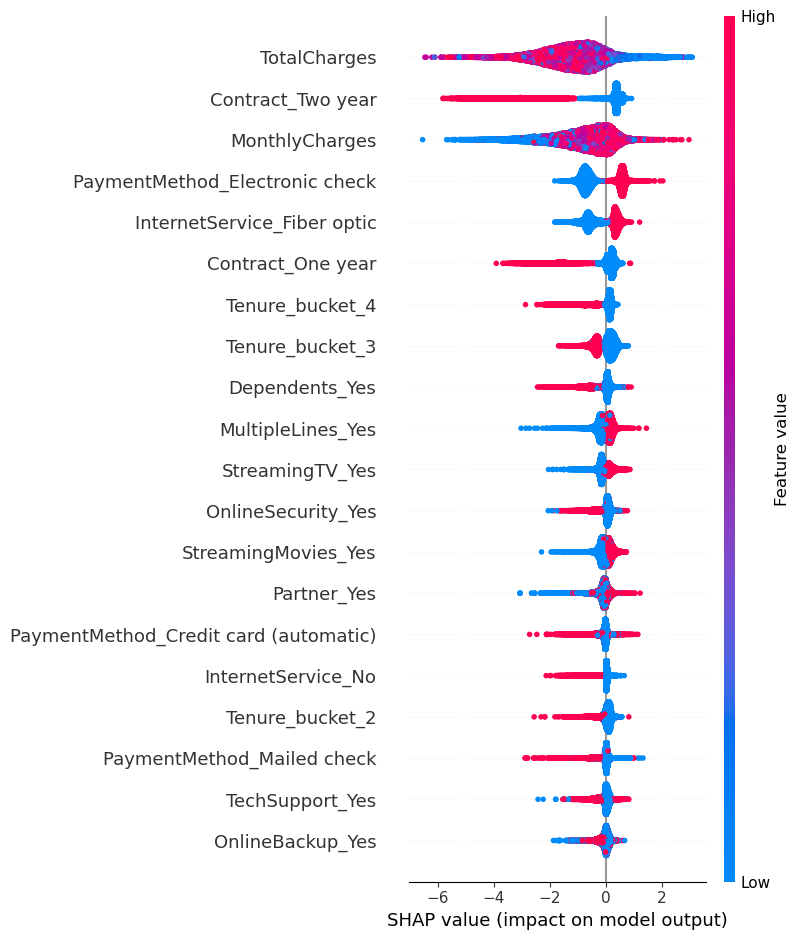

In [125]:
import shap

# gunakan validation set
X_shap = x_val.copy()

explainer = shap.TreeExplainer(xgb_final)
shap_values = explainer.shap_values(X_shap)

shap.summary_plot(
    shap_values,
    X_shap,
    show=True
)

# evaluate

In [127]:
# TEST EVALUATION
start_time = time.perf_counter()

# TEST metrics
test_metrics = evaluate_model(
    xgb_model,
    x_test,
    y_test,
    threshold=0.5
)

# TEST prediction
y_test_prob = xgb_model.predict_proba(x_test)[:, 1]
y_test_pred = (y_test_prob >= 0.5).astype(int)

# SAVE classification report
test_report_path = save_classification_report_image(
    y_true=y_test,
    y_pred=y_test_pred,
    model_name="xgboost",
    train_type="no_ros",
    stage="test",
)

elapsed = time.perf_counter() - start_time

# LOG PAYLOAD (TEST)
log_payload = {
    "stage": "test_evaluation",
    "train_type": "no_ros",
    "model": "xgboost",
    "time_sec": round(elapsed, 2),

    # TEST METRICS
    "test_recall": test_metrics["recall"],
    "test_pr_auc": test_metrics["pr_auc"],
    "test_roc_auc": test_metrics["roc_auc"],

    # ARTIFACT
    "test_report_path": test_report_path,
}

test_logger.info(log_payload)


2026-03-06 11:34:51,800 | INFO | {'stage': 'test_evaluation', 'train_type': 'no_ros', 'model': 'xgboost', 'time_sec': 1.62, 'test_recall': 0.9188462113286504, 'test_pr_auc': 0.724295033154295, 'test_roc_auc': 0.9017042887621527, 'test_report_path': 'artifacts\\reports\\test_xgboost_no_ros_classification_report.png'}


In [128]:
# CONFIG
ARTIFACT_DIR = Path("artifacts") / "models"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

model_path = ARTIFACT_DIR / "xgb_ros.pkl"

# SAVE MODEL
joblib.dump(xgb_model, model_path)
print(f"Model saved to: {model_path}")

Model saved to: artifacts\models\xgb_ros.pkl


# Inference Model

In [129]:
# PATH
ARTIFACT_DIR = Path("artifacts")

MODEL_PATH = ARTIFACT_DIR / "models" / "xgb_ros.pkl"
PREPROCESS_PATH = ARTIFACT_DIR / "preprocessing_fe" / "preprocessing_artifacts.joblib"

# LOAD
model = joblib.load(MODEL_PATH)
preprocess = joblib.load(PREPROCESS_PATH)

print("Model & preprocessing loaded")

Model & preprocessing loaded


In [130]:
preprocess

{'scaler': StandardScaler(),
 'ohe_preprocess': ColumnTransformer(remainder='passthrough',
                   transformers=[('cat_ohe',
                                  OneHotEncoder(drop='first',
                                                handle_unknown='ignore',
                                                sparse_output=False),
                                  ['Partner', 'Dependents', 'PhoneService',
                                   'MultipleLines', 'InternetService',
                                   'OnlineSecurity', 'OnlineBackup',
                                   'DeviceProtection', 'TechSupport',
                                   'StreamingTV', 'StreamingMovies', 'Contract',
                                   'PaymentMethod', 'Tenure_bucket'])]),
 'log_cols': ['MonthlyCharges', 'TotalCharges'],
 'cont_cols': ['MonthlyCharges', 'TotalCharges']}

In [131]:
# load preprocess
scaler = preprocess["scaler"]
ohe = preprocess["ohe_preprocess"]
log_cols = preprocess["log_cols"]
cont_cols = preprocess["cont_cols"]

In [132]:
feature_names = preprocess["ohe_preprocess"].get_feature_names_out()
feature_names

array(['cat_ohe__Partner_Yes', 'cat_ohe__Dependents_Yes',
       'cat_ohe__PhoneService_Yes',
       'cat_ohe__MultipleLines_No phone service',
       'cat_ohe__MultipleLines_Yes',
       'cat_ohe__InternetService_Fiber optic',
       'cat_ohe__InternetService_No',
       'cat_ohe__OnlineSecurity_No internet service',
       'cat_ohe__OnlineSecurity_Yes',
       'cat_ohe__OnlineBackup_No internet service',
       'cat_ohe__OnlineBackup_Yes',
       'cat_ohe__DeviceProtection_No internet service',
       'cat_ohe__DeviceProtection_Yes',
       'cat_ohe__TechSupport_No internet service',
       'cat_ohe__TechSupport_Yes',
       'cat_ohe__StreamingTV_No internet service',
       'cat_ohe__StreamingTV_Yes',
       'cat_ohe__StreamingMovies_No internet service',
       'cat_ohe__StreamingMovies_Yes', 'cat_ohe__Contract_One year',
       'cat_ohe__Contract_Two year',
       'cat_ohe__PaymentMethod_Credit card (automatic)',
       'cat_ohe__PaymentMethod_Electronic check',
       'cat_ohe__P

In [133]:
preprocess["ohe_preprocess"].transformers_[0][2]

['Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaymentMethod',
 'Tenure_bucket']

In [134]:
preprocess["cont_cols"]

['MonthlyCharges', 'TotalCharges']

In [135]:
def apply_binning(df):
    df = df.copy()

    df["Tenure_bucket"] = pd.cut(
        df["tenure"],
        bins=TENURE_BINS,
        labels=TENURE_LABELS,
        include_lowest=True
    ).astype(int)

    return df

def inference_pipeline(raw_df, preprocess, model):
    df = raw_df.copy()

    # BINNING
    df = apply_binning(df)

    # LOG TRANSFORM
    for col in preprocess["log_cols"]:
        df[col] = np.log1p(df[col])

    # SCALING
    df[preprocess["cont_cols"]] = preprocess["scaler"].transform(
        df[preprocess["cont_cols"]]
    )

    # OHE + remainder
    X = preprocess["ohe_preprocess"].transform(df)

    # PREDICT
    proba = model.predict_proba(X)[:, 1]
    pred = (proba >= 0.5).astype(int)

    return pred, proba


In [142]:
print(df_test[-1:])

            id  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
254654  848848  Female              0      No         No      24          Yes   

       MultipleLines InternetService OnlineSecurity OnlineBackup  \
254654           Yes     Fiber optic             No           No   

       DeviceProtection TechSupport StreamingTV StreamingMovies  \
254654              Yes          No         Yes              No   

              Contract PaperlessBilling            PaymentMethod  \
254654  Month-to-month              Yes  Credit card (automatic)   

        MonthlyCharges  TotalCharges  
254654            90.1       2172.05  


In [136]:
df_test.columns.tolist()

['id',
 'gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'tenure',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'MonthlyCharges',
 'TotalCharges']

In [159]:
raw = df_test[55:56]
raw

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
55,594249,Female,0,Yes,Yes,6,Yes,No,DSL,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,49.1,297.35


In [160]:
# check data
X = preprocess["ohe_preprocess"].transform(
    apply_binning(raw)
)

X_train_ros = joblib.load("artifacts/preprocessing_fe/x_train_ros.joblib")

assert X.shape[1] == X_train_ros.shape[1], "kolom tidak sama"

print('kolom sama', X.shape[1], X_train_ros.shape[1])

kolom sama 30 30


In [161]:
# predict
pred, proba = inference_pipeline(raw, preprocess, model)

proba_val = float(proba[0])
pred_val = int(pred[0])

if proba >= 0.8:
    risk = "HIGH"
elif proba >= 0.5:
    risk = "MEDIUM"
else:
    risk = "LOW"

print("Prediction:", pred_val)
print("Probability:", proba_val)
print("Risk level:", risk)

Prediction: 1
Probability: 0.6592772006988525
Risk level: MEDIUM
